# Healthcare Data Analysis Capstone Project

## Business Objective
The main purpose of this project is to understand how multiple hospitals or hospital branches
are performing using data. This project analyzes patients, doctors, appointments, billing,
and treatments to find business problems and improvement areas. The goal is to help hospital
management make better decisions related to operations, revenue, and patient care.

## Data Source & Nature of Dataset
The dataset used in this project is synthetically generated to resemble real-world
healthcare data. The data was created for learning and demonstration purposes and does
not belong to any real hospital or patient.

## Data Overview
This project uses a synthetically generated healthcare dataset that represents operations
across multiple hospitals or branches. The data includes information related to patients,
doctors, appointments, billing, and treatments. Together, these datasets provide an overall
view of hospital operations, patient flow, and revenue performance

## Key Business Questions Answered
- How are patient registrations and appointments changing over time?
- Which cities, doctors, and specializations contribute the most to patient volume and revenue?
- How evenly is doctor workload distributed across specializations?
- When do appointment cancellations and no-shows occur most frequently?
- Is hospital revenue growing and how does billing compare with appointment activity?
- Are there gaps between completed appointments and actual billing?
- Which treatments generate high revenue and which are underutilized?

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Dataset

In [2]:
# Patients Table
df1 = pd.read_csv('C:\\Users\\Shubham\\Downloads\\Study_Work\\Capstone Projects\\Health Care Project\\Raw Dataset\\patients.csv')
# df1.head()

# Doctors Table
df2 = pd.read_csv('C:\\Users\\Shubham\\Downloads\\Study_Work\\Capstone Projects\\Health Care Project\\Raw Dataset\\doctors.csv')
# df2.head()

# Billing Table
df3 = pd.read_csv('C:\\Users\\Shubham\\Downloads\\Study_Work\\Capstone Projects\\Health Care Project\\Raw Dataset\\billing.csv')
# df3.head()

# Appointments Table
df4 = pd.read_csv('C:\\Users\\Shubham\\Downloads\\Study_Work\\Capstone Projects\\Health Care Project\\Raw Dataset\\appointments.csv')
# df4.head()

# Treatment Table
df5 = pd.read_csv('C:\\Users\\Shubham\\Downloads\\Study_Work\\Capstone Projects\\Health Care Project\\Raw Dataset\\treatment.csv')
# df5.head()

### Data Cleaning

#### Patients Table

##### 1) Handling Data Types

In [3]:
df1.dtypes

patient_id            object
first_name            object
last_name             object
gender                object
age                   object
dob                   object
contact_no            object
address               object
reg_date              object
insurance_provider    object
insurance_no          object
email                 object
dtype: object

In [4]:
# df1['dob'] = pd.to_datetime(df1['dob'])

###### As there are different dates formats in dob column, replacing all with 'YYYY-MM-DD' format.

In [5]:
# Converting Data Type of age column to float
df1['age'] = pd.to_numeric(df1['age'],errors='coerce')

In [6]:
# Making copy of df1['dob']
df1['dob_raw'] = df1['dob'].copy()

# Converting 'YYYY-MM-DD' format strings to datetime
df1['dob_clean'] = pd.to_datetime(df1['dob_raw'],errors='coerce')

# Converting 'DD-MM-YYYY' format strings to datetime in 'YYYY-MM-DD' format
a = df1['dob_clean'].isnull()
df1.loc[a,'dob_clean'] = pd.to_datetime(df1.loc[a,'dob_raw'],dayfirst=True,errors='coerce')

# Converting 'MM-DD-YYYY' format strings to datetime in 'YYYY-MM-DD' format
b = df1['dob_clean'].isnull()
df1.loc[b,'dob_clean'] = pd.to_datetime(df1.loc[b,'dob_raw'],dayfirst=False,errors='coerce')

In [7]:
# Droopping columns dob and dob_raw and renaming column dob_clean to dob.
df1.drop(['dob','dob_raw'],axis=1,inplace=True)
df1.rename(columns={'dob_clean':'dob'},inplace=True)

In [8]:
df1.columns

Index(['patient_id', 'first_name', 'last_name', 'gender', 'age', 'contact_no',
       'address', 'reg_date', 'insurance_provider', 'insurance_no', 'email',
       'dob'],
      dtype='object')

In [9]:
# df1['reg_date'] = pd.to_datetime(df1['reg_date']) 

###### As there are different dates formats in reg_date column, replacing all with 'YYYY-MM-DD' format. 

In [10]:
# Making copy of df1['reg_date']
df1['reg_raw'] = df1['reg_date'].copy()

# Converting 'YYYY-MM-DD' format strings to datetime
df1['reg_date_clean'] = pd.to_datetime(df1['reg_raw'],errors='coerce')

# Converting 'DD-MM-YYYY' format strings to datetime in 'YYYY-MM-DD' format
a = df1['reg_date_clean'].isnull()
df1.loc[a,'reg_date_clean'] = pd.to_datetime(df1.loc[a,'reg_raw'],dayfirst=True,errors='coerce')

# Converting 'MM-DD-YYYY' format strings to datetime in 'YYYY-MM-DD' format
b = df1['reg_date_clean'].isnull()
df1.loc[b,'reg_date_clean'] = pd.to_datetime(df1.loc[b,'reg_raw'],dayfirst=False,errors='coerce')

In [11]:
# Dropping col reg_date and reg_raw 
df1.drop(['reg_date','reg_raw'],axis=1,inplace=True)

In [12]:
# Renaming column 'reg_date_clean' to 'reg_date'
df1.rename(columns={'reg_date_clean':'reg_date'},inplace=True)

In [13]:
df1.columns

Index(['patient_id', 'first_name', 'last_name', 'gender', 'age', 'contact_no',
       'address', 'insurance_provider', 'insurance_no', 'email', 'dob',
       'reg_date'],
      dtype='object')

In [14]:
df1.dtypes

patient_id                    object
first_name                    object
last_name                     object
gender                        object
age                          float64
contact_no                    object
address                       object
insurance_provider            object
insurance_no                  object
email                         object
dob                   datetime64[ns]
reg_date              datetime64[ns]
dtype: object

##### 2) Handling Null Values

In [15]:
df1.isnull().sum()

patient_id              0
first_name            210
last_name             209
gender                209
age                    54
contact_no              0
address               214
insurance_provider      0
insurance_no          214
email                 214
dob                     0
reg_date                0
dtype: int64

In [16]:
# Filling null values in first and last name with 'Unknown'.
df1['first_name'] = df1['first_name'].fillna('Unknown')
df1['last_name'] = df1['last_name'].fillna('Unknown')

In [17]:
df1['gender'].value_counts()

gender
Male      4229
Female    4213
M         1038
F         1030
male         4
female       1
Name: count, dtype: int64

In [18]:
# Replacing M,male with Male and f,female with Female.
df1['gender'] = df1['gender'].replace({'M':'Male','male':'Male','F':'Female','female':'Female'}) 
df1['gender'].value_counts()

gender
Male      5271
Female    5244
Name: count, dtype: int64

In [19]:
# Filling null values in gender column with 'Unknown'.
df1['gender'] = df1['gender'].fillna('Unknown') 

In [20]:
# Filling null values in address column with 'Not Available'.
df1['address'] = df1['address'].fillna('Not Available')

In [21]:
# Filling null values in insurance_no column with 'Not Available'
df1['insurance_no'] = df1['insurance_no'].fillna('Not Available')

In [22]:
# Filling null values in email column with 'Not Provided'
df1['email'] = df1['email'].fillna('Not Provided')

In [23]:
df1.isnull().sum()

patient_id             0
first_name             0
last_name              0
gender                 0
age                   54
contact_no             0
address                0
insurance_provider     0
insurance_no           0
email                  0
dob                    0
reg_date               0
dtype: int64

##### 3) Handling Duplicates

In [24]:
df1.duplicated().sum()

10

In [25]:
# dropping duplicate rows
df1.drop_duplicates(inplace=True)

In [26]:
df1.duplicated().sum()

0

##### 4) Handling Outliers

In [27]:
df1.describe(percentiles=[0.01,0.02,0.03,0.05,0.25,0.50,0.75,0.95,0.97,0.98,0.99]).T

,count,mean,min,1%,2%,3%,5%,25%,50%,75%,95%,97%,98%,99%,max,std
age,10660.0,48.342589,1.0,1.0,2.0,3.0,5.0,24.0,48.0,72.0,91.0,93.0,94.0,95.0,179.0,28.05339
dob,10714,1977-06-18 23:34:35.863356352,1930-01-02 00:00:00,1931-01-24 21:50:24,1932-01-06 12:28:48,1932-11-24 09:21:36,1934-11-06 00:00:00,1953-09-05 00:00:00,1977-07-08 12:00:00,2001-06-04 00:00:00,2020-03-18 09:36:00,2022-03-08 14:38:24,2023-02-07 16:48:00,2024-02-04 14:38:24.000000256,2024-12-30 00:00:00,NaN
reg_date,10714,2023-05-25 21:40:29.344782592,2021-01-01 00:00:00,2021-01-16 00:00:00,2021-02-02 00:00:00,2021-02-18 09:21:36,2021-03-26 15:36:00,2022-03-13 00:00:00,2023-06-02 00:00:00,2024-08-02 18:00:00,2025-08-03 00:00:00,2025-09-08 14:38:24,2025-09-29 00:00:00,2025-10-13 00:00:00,2025-10-31 00:00:00,NaN


In [28]:
# Checking the shape where age > 120
df1[df1['age']>120.0].shape

(32, 12)

In [29]:
# Replacing age with 120 where age > 120 else original age
df1['age'] = np.where(df1['age']>120.0,120.0,df1['age'])

In [30]:
df1.describe(percentiles=[0.01,0.02,0.03,0.05,0.25,0.50,0.75,0.95,0.97,0.98,0.99]).T

,count,mean,min,1%,2%,3%,5%,25%,50%,75%,95%,97%,98%,99%,max,std
age,10660.0,48.234428,1.0,1.0,2.0,3.0,5.0,24.0,48.0,72.0,91.0,93.0,94.0,95.0,120.0,27.696218
dob,10714,1977-06-18 23:34:35.863356352,1930-01-02 00:00:00,1931-01-24 21:50:24,1932-01-06 12:28:48,1932-11-24 09:21:36,1934-11-06 00:00:00,1953-09-05 00:00:00,1977-07-08 12:00:00,2001-06-04 00:00:00,2020-03-18 09:36:00,2022-03-08 14:38:24,2023-02-07 16:48:00,2024-02-04 14:38:24.000000256,2024-12-30 00:00:00,NaN
reg_date,10714,2023-05-25 21:40:29.344782592,2021-01-01 00:00:00,2021-01-16 00:00:00,2021-02-02 00:00:00,2021-02-18 09:21:36,2021-03-26 15:36:00,2022-03-13 00:00:00,2023-06-02 00:00:00,2024-08-02 18:00:00,2025-08-03 00:00:00,2025-09-08 14:38:24,2025-09-29 00:00:00,2025-10-13 00:00:00,2025-10-31 00:00:00,NaN


In [31]:
print('Median:',df1['age'].median())
print('Mean:',df1['age'].mean())

Median: 48.0
Mean: 48.234427767354596


In [32]:
# After handling outliers, filling null values in age column with Median.
df1['age'] = df1['age'].fillna(df1['age'].median())

In [33]:
df1.isnull().sum()

patient_id            0
first_name            0
last_name             0
gender                0
age                   0
contact_no            0
address               0
insurance_provider    0
insurance_no          0
email                 0
dob                   0
reg_date              0
dtype: int64

##### 5) Handling Data Inconsistency

In [34]:
print(df1[df1['reg_date']<df1['dob']].shape)

(192, 12)


In [35]:
# Some patients have reg_date earlier than dob (which is logically impossible).
# reg_date are treated as NaN to maintain data integrity
mask = df1[df1['reg_date'] < df1['dob']].index
df1.loc[mask,'reg_date'] = pd.NaT

In [36]:
# Checking error rows
df1[df1['reg_date'] < df1['dob']].shape

(0, 12)

#### Doctors Table

##### 1) Handling Null Values

In [37]:
# df2[df2.isnull().sum(axis=1)>0].index

In [38]:
df2.isnull().sum()

doctor_id         0
fname             6
lname             6
specialization    0
contact_no        0
experience        0
branch            4
email             4
dtype: int64

In [39]:
# Replacing null values in fname and lname with 'Unknown'.
df2['fname'] = df2['fname'].fillna('Unknown')
df2['lname'] = df2['lname'].fillna('Unknown')

In [40]:
df2.dtypes

doctor_id         object
fname             object
lname             object
specialization    object
contact_no        object
experience        object
branch            object
email             object
dtype: object

In [41]:
# Replacing null values in column branch with mode and email with 'Not Provided'
df2['branch'] = df2['branch'].fillna(df2['branch'].mode()[0])
df2['email'] = df2['email'].fillna('Not Provided')

In [42]:
df2.isnull().sum()

doctor_id         0
fname             0
lname             0
specialization    0
contact_no        0
experience        0
branch            0
email             0
dtype: int64

##### 2) Handling Duplicates

In [43]:
# Identifying deplicate rows
df2.duplicated().sum()

5

In [44]:
# Deleting duplicate rows
df2.drop_duplicates(inplace=True)

In [45]:
df2.duplicated().sum()

0

##### 3) Standardizing Data

In [46]:
df2.columns

Index(['doctor_id', 'fname', 'lname', 'specialization', 'contact_no',
       'experience', 'branch', 'email'],
      dtype='object')

In [47]:
df2['experience'].unique()

array(['32', '10', '28', '23', '35', '17', '24', '26', '15', '8', '21',
       '9', '5', '33', '13', '31', '14', '16', '29', '11', '37', '19',
       '30', '20', '3', '18', 'five', '7', '4', '27', '12', '34', '25',
       '36', '22', '6', 'ten'], dtype=object)

In [48]:
# Converting string 'five' into 5 and 'ten' into 10
df2['experience'] = df2['experience'].replace({'five':'5','ten':'10'})

##### 3) Handling Data Types

In [49]:
df2.dtypes

doctor_id         object
fname             object
lname             object
specialization    object
contact_no        object
experience        object
branch            object
email             object
dtype: object

In [50]:
# Changing Data Type of column Experience to int
df2['experience'] = df2['experience'].astype(int)

In [51]:
df2.dtypes

doctor_id         object
fname             object
lname             object
specialization    object
contact_no        object
experience         int32
branch            object
email             object
dtype: object

##### 5) Handling Outliers

In [52]:
df2.describe(percentiles=[0.01,0.02,0.03,0.05,0.25,0.50,0.75,0.95,0.97,0.98,0.99]).T

,count,mean,std,min,1%,2%,3%,5%,25%,50%,75%,95%,97%,98%,99%,max
experience,200.0,21.1,10.378757,3.0,3.0,4.0,4.0,5.0,12.0,21.0,31.0,36.05,37.0,37.0,37.0,37.0


In [53]:
# The statistical summary did not indicate the presence of any unusual extreme values.

#### Billing Table

##### 1) Handling Data Types

In [54]:
df3.dtypes

bill_id             object
patient_id          object
treatment_id        object
bill_date           object
amount              object
payment_method      object
payment_status      object
reason_for_visit    object
appointment_id      object
dtype: object

In [55]:
# df3['bill_date'] = pd.to_datetime(df3['bill_date'])

###### As there are different dates formats in bill_date column, replacing all with 'YYYY-MM-DD' format.

In [56]:
# Converting 'YYYY-MM-DD' format strings to datetime
df3['bill_date_clean'] = pd.to_datetime(df3['bill_date'],errors='coerce')

# Converting 'DD-MM-YYYY' format strings to datetime in 'YYYY-MM-DD' format
a = df3['bill_date_clean'].isnull()
df3.loc[a,'bill_date_clean'] = pd.to_datetime(df3.loc[a,'bill_date'],dayfirst=True,errors='coerce')

# Converting 'MM-DD-YYYY' format strings to datetime in 'YYYY-MM-DD' format
b = df3['bill_date_clean'].isnull()
df3.loc[b,'bill_date_clean'] = pd.to_datetime(df3.loc[b,'bill_date'],dayfirst=False,errors='coerce')

In [57]:
# Dropping Column bill_date and renaming column bill_date_clean with bill_date
df3.drop('bill_date',axis=1,inplace=True)
df3.rename(columns={'bill_date_clean':'bill_date'},inplace=True)

In [58]:
# Converting Data type of column amount with int and replacing other with nulls.
df3['amount'] = pd.to_numeric(df3['amount'],errors='coerce')

In [59]:
df3['amount'].isnull().sum()

353

In [60]:
df3.dtypes

bill_id                     object
patient_id                  object
treatment_id                object
amount                     float64
payment_method              object
payment_status              object
reason_for_visit            object
appointment_id              object
bill_date           datetime64[ns]
dtype: object

##### 2) Handling Null Values

In [61]:
df3.isnull().sum()

bill_id                0
patient_id             0
treatment_id        7508
amount               353
payment_method         0
payment_status       285
reason_for_visit       0
appointment_id         0
bill_date              0
dtype: int64

In [62]:
print(df3[(df3['treatment_id'].isnull()) & (df3['amount'].isnull()) & (df3['payment_status'].isnull())].shape)
drop_idx = df3[(df3['treatment_id'].isnull()) & (df3['amount'].isnull()) & (df3['payment_status'].isnull())].index
drop_idx

(137, 9)


Index([  157,   513,   529,   622,   628,   629,   630,   751,   833,   903,
       ...
       13539, 13654, 13743, 13887, 13912, 14028, 14142, 14214, 14230, 14242],
      dtype='int64', length=137)

In [63]:
df3.shape

(14260, 9)

In [64]:
df3.drop(drop_idx,inplace=True)

In [65]:
df3.shape

(14123, 9)

In [66]:
# Identified and removed 136 billing records where treatment_id, amount, and payment_status were simultaneously missing,
# as they contain no meaningful billing information, they were removed to maintain data quality.

In [67]:
df3.isnull().sum()

bill_id                0
patient_id             0
treatment_id        7371
amount               216
payment_method         0
payment_status       148
reason_for_visit       0
appointment_id         0
bill_date              0
dtype: int64

In [68]:
# df3[ (df3['amount'].isnull()) & (df3['payment_status'].isnull()) ].shape
drop_idx = df3[ (df3['amount'].isnull()) & (df3['payment_status'].isnull()) ].index
drop_idx

Index([  182,   305,   374,   505,   573,   579,   588,   649,   867,   950,
       ...
       13679, 13717, 13724, 13739, 13795, 13839, 14070, 14110, 14156, 14180],
      dtype='int64', length=148)

In [69]:
df3.shape

(14123, 9)

In [70]:
df3.drop(drop_idx,inplace=True)

In [71]:
df3.shape

(13975, 9)

In [72]:
# Dropped 149 billing records where both amount and payment_status were missing, as they lacked essential financial information
# and could not be reliably recovered.

In [73]:
# Replacing null values in amount column with median.
print(df3['amount'].median())
print(df3['amount'].mean())

1093.0
12483.455525994104


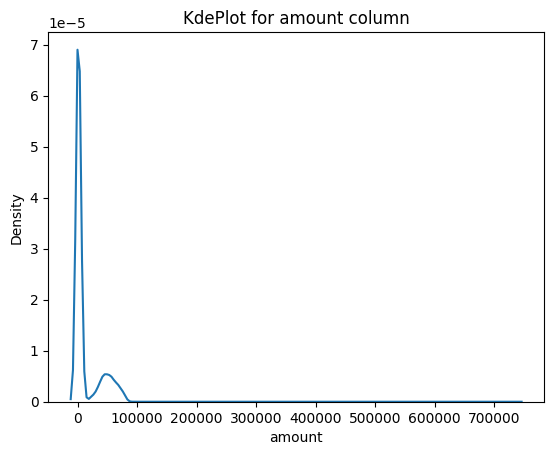

In [74]:
sns.kdeplot(data=df3,x='amount')
plt.title(f'KdePlot for amount column')
plt.show()

In [75]:
# Amount column is right skewed so replacing null values with median
df3['amount'] = df3['amount'].fillna(df3['amount'].median())

In [76]:
print('billing:\n',df3.columns)
print('treatment:\n',df5.columns)

billing:
 Index(['bill_id', 'patient_id', 'treatment_id', 'amount', 'payment_method',
       'payment_status', 'reason_for_visit', 'appointment_id', 'bill_date'],
      dtype='object')
treatment:
 Index(['treatment_id', 'appointment_id', 'treatment_type', 'description',
       'cost', 'treatment_date'],
      dtype='object')


In [77]:
merge = pd.merge(df3,df5,on='appointment_id',how='left')
merge[( merge['treatment_id_x'].isnull()) & (merge['treatment_id_y'].notna()) ].shape

(0, 14)

In [78]:
# A left join was performed between the billing and treatment tables to recover missing treatment_id values,
# however no valid matches were found.

In [79]:
df3.isnull().sum()

bill_id                0
patient_id             0
treatment_id        7371
amount                 0
payment_method         0
payment_status         0
reason_for_visit       0
appointment_id         0
bill_date              0
dtype: int64

In [80]:
# treatment_id was kept as NaN to preserve data integrity, 'Unknown' is applied only for display/visualization  when required.

##### 3) Handling Duplicates

In [81]:
df3.duplicated().sum()

10

In [82]:
df3.drop_duplicates(inplace=True)

In [83]:
df3.duplicated().sum()

0

In [84]:
df3.head()

,bill_id,patient_id,treatment_id,amount,payment_method,payment_status,reason_for_visit,appointment_id,bill_date
0,B00001,P10265,NaN,844.0,UPI,Pending,Consultation,A00001,2025-05-19
1,B00002,P03285,NaN,934.0,Cash,Paid,Routine Check-Up,A00002,2025-11-05
2,B00003,P06308,NaN,948.0,Insurance,Paid,Consultation,A00003,2025-10-20
3,B00004,P00322,NaN,768.0,UPI,Pending,Routine Check-Up,A00004,2024-05-16
4,B00005,P05581,NaN,742.0,Insurance,Paid,Routine Check-Up,A00005,2024-05-01


In [85]:
# df3['appointment_id'].sample(50)

##### 4) Handling Data Inconsistency

In [86]:
merge = pd.merge(df1,df3,left_on='patient_id',right_on='patient_id',how='inner')
drop_bill_id = merge[ merge['bill_date'] < merge['dob'] ]['bill_id'].values
print(len(drop_bill_id))
# drop_bill_id

114


array(['B02542', 'B03068', 'B06143', 'B07513', 'B07514', 'B05992',
       'B12452', 'B12454', 'B10071', 'B10072', 'B00769', 'B01823',
       'B06717', 'B05402', 'B06342', 'B04445', 'B08541', 'B13233',
       'B04673', 'B06394', 'B05558', 'B10114', 'B09244', 'B09245',
       'B13563', 'B13564', 'B14051', 'B14052', 'B04678', 'B10579',
       'B05522', 'B06537', 'B13844', 'B07992', 'B03119', 'B09165',
       'B09166', 'B04636', 'B12842', 'B12843', 'B00376', 'B04821',
       'B07702', 'B07703', 'B13259', 'B00485', 'B11193', 'B08566',
       'B09652', 'B09653', 'B02555', 'B05509', 'B08602', 'B01978',
       'B01351', 'B02649', 'B04913', 'B10064', 'B06951', 'B05079',
       'B01398', 'B03422', 'B10073', 'B10074', 'B02665', 'B01071',
       'B05836', 'B08507', 'B08508', 'B03434', 'B00120', 'B01305',
       'B12959', 'B12960', 'B02011', 'B00888', 'B06973', 'B11747',
       'B11748', 'B11749', 'B01940', 'B04805', 'B03797', 'B07152',
       'B07153', 'B13290', 'B13291', 'B10215', 'B07103', 'B071

In [87]:
df3 = df3[~df3['bill_id'].isin(drop_bill_id)]

In [88]:
# 114 billing records were found where the bill_date was earlier than the patient's dob whiich is not logically possible,
# these incorrect records were removed to maintain clean and reliable data.

In [89]:
# Checking for reg_date
merge = pd.merge(df1,df3,left_on='patient_id',right_on='patient_id',how='inner')
print(merge[ merge['reg_date'] < merge['dob'] ].shape)

(0, 20)


In [90]:
df3.shape

(13851, 9)

#### Appointments Table

##### 1) Handling Data Types

In [91]:
df4.dtypes

ap_id               object
patient_id          object
doctor_id           object
ap_date             object
ap_time             object
reason_for_visit    object
status              object
dtype: object

In [92]:
# df4['ap_date'] = pd.to_datetime(df4['ap_date'])

###### As there are different dates formats in ap_date column, replacing all with 'YYYY-MM-DD' format.

In [93]:
# Converting 'YYYY-MM-DD' format strings to datetime
df4['ap_date_clean'] = pd.to_datetime(df4['ap_date'],errors='coerce')

# Converting 'DD-MM-YYYY' format strings to datetime in 'YYYY-MM-DD' format 
a = df4['ap_date_clean'].isnull()
df4.loc[a,'ap_date_clean'] = pd.to_datetime(df4.loc[a,'ap_date'],dayfirst=True,errors='coerce')

# Converting 'MM-DD-YYYY' format strings to datetime in 'YYYY-MM-DD' format
b = df4['ap_date_clean'].isnull()
df4.loc[b,'ap_date_clean'] = pd.to_datetime(df4.loc[b,'ap_date'],dayfirst=False,errors='coerce')

In [94]:
# Dropping ap_date column and renaming column ap_date_clean to ap_date
df4.drop('ap_date',axis=1,inplace=True)
df4.rename(columns={'ap_date_clean':'ap_date'},inplace=True)

In [95]:
df4.columns

Index(['ap_id', 'patient_id', 'doctor_id', 'ap_time', 'reason_for_visit',
       'status', 'ap_date'],
      dtype='object')

In [96]:
import warnings
warnings.filterwarnings('ignore')

In [97]:
# Converting Data Type of ap_time to datetime
df4['ap_time'] = pd.to_datetime(df4['ap_time']).dt.time
df4['ap_time'] = pd.to_datetime(df4['ap_time'], format="%H:%M:%S")

In [98]:
df4.dtypes

ap_id                       object
patient_id                  object
doctor_id                   object
ap_time             datetime64[ns]
reason_for_visit            object
status                      object
ap_date             datetime64[ns]
dtype: object

##### 2) Standardizing Data

In [99]:
df4['status'].unique()

array(['Cancelled', 'Completed', 'Scheduled', 'No-Show', nan,
       '  completed  '], dtype=object)

In [100]:
# Replacing inconsistent text formatting (extra spaces) with a clean value 'Completed'.
df4['status'] = df4['status'].replace({'  completed  ':'Completed'})

In [101]:
df4['status'].unique()

array(['Cancelled', 'Completed', 'Scheduled', 'No-Show', nan],
      dtype=object)

In [102]:
df4['reason_for_visit'].unique()

array(['Consultation', 'Routine Check-Up', 'Diagnosis', 'Follow-up',
       'Treatment', nan], dtype=object)

##### 3) Handling Null Values

In [103]:
df4.isnull().sum()

ap_id                 0
patient_id            0
doctor_id             0
ap_time               0
reason_for_visit    300
status              296
ap_date               0
dtype: int64

In [104]:
df4.shape

(15010, 7)

In [105]:
df4['status'].value_counts()

status
Completed    10336
Scheduled     2197
Cancelled     1502
No-Show        679
Name: count, dtype: int64

In [106]:
# Filling null values in column status with mode
df4['status'] = df4['status'].fillna(df4['status'].mode()[0])

In [107]:
df4['reason_for_visit'].value_counts(normalize=True)

reason_for_visit
Consultation        0.300068
Diagnosis           0.249490
Routine Check-Up    0.200544
Treatment           0.200000
Follow-up           0.049898
Name: proportion, dtype: float64

In [108]:
# Doing proportional filling in column 'reason_for_visit' because no single category is overwhelmingly dominant.
null_val_idx = df4[df4['reason_for_visit'].isnull()].index
print(null_val_idx.shape)
null_val_idx

(300,)


Index([   35,    88,    95,   155,   287,   389,   397,   404,   406,   425,
       ...
       14443, 14462, 14464, 14532, 14537, 14650, 14659, 14666, 14835, 14924],
      dtype='int64', length=300)

In [109]:
fill_null_vals = np.random.choice(['Consultation','Diagnosis','Routine Check-Up','Treatment','Follow-up'],size=300,
                                 p=[0.300220,0.249348,0.200604,0.199986,0.049842])
fill_null_vals.shape

(300,)

In [110]:
df4.loc[null_val_idx,'reason_for_visit'] = fill_null_vals

In [111]:
df4.isnull().sum()

ap_id               0
patient_id          0
doctor_id           0
ap_time             0
reason_for_visit    0
status              0
ap_date             0
dtype: int64

##### 4) Handling Duplicates

In [112]:
df4.duplicated().sum()

10

In [113]:
df4.drop_duplicates(inplace=True)

In [114]:
df4.duplicated().sum()

0

In [115]:
df4.head()

,ap_id,patient_id,doctor_id,ap_time,reason_for_visit,status,ap_date
0,A00001,P10265,D131,1900-01-01 09:15:00,Consultation,Cancelled,2025-05-13
1,A00002,P03285,D018,1900-01-01 15:15:00,Routine Check-Up,Completed,2025-10-31
2,A00003,P06308,D060,1900-01-01 18:45:00,Consultation,Completed,2025-10-20
3,A00004,P00322,D030,1900-01-01 12:30:00,Routine Check-Up,Completed,2024-05-13
4,A00005,P05581,D071,1900-01-01 14:30:00,Routine Check-Up,Scheduled,2024-04-29


#### Treatment Table

##### 1) Handling Data Types

In [116]:
df5.dtypes

treatment_id      object
appointment_id    object
treatment_type    object
description       object
cost              object
treatment_date    object
dtype: object

In [117]:
# Changing Data Type of column cost to int 
df5['cost'] = pd.to_numeric(df5['cost'],errors='coerce')

In [118]:
df5['treatment_date'] = pd.to_datetime(df5['treatment_date'])

In [119]:
df5.dtypes

treatment_id              object
appointment_id            object
treatment_type            object
description               object
cost                     float64
treatment_date    datetime64[ns]
dtype: object

##### 2) Handling Null Values

In [120]:
df5.isnull().sum()

treatment_id        0
appointment_id      0
treatment_type      0
description       135
cost              103
treatment_date      0
dtype: int64

In [121]:
# df5[df5['description'].isnull()]

In [122]:
# Checking that each treatment_type has only one description or not.
df5.groupby('treatment_type')['description'].nunique()

treatment_type
Appendectomy         1
CT Scan              1
Chemotherapy         1
ECG                  1
Hernia Repair        1
MRI Scan             1
Radiation Therapy    1
Stress Test          1
X-Ray                1
Name: description, dtype: int64

In [123]:
df5['treatment_type'].unique()

array(['MRI Scan', 'Appendectomy', 'ECG', 'Radiation Therapy',
       'Hernia Repair', 'Chemotherapy', 'CT Scan', 'Stress Test', 'X-Ray'],
      dtype=object)

In [124]:
df5['description'].unique()

array(['Brain Imaging', 'Appendix Removal', 'Heart Analysis',
       'Tumor Reduction', 'Muscle Correction', nan, 'Body Imaging',
       'Cardiac Evaluation', 'Bone Imaging', 'Cancer Treatment'],
      dtype=object)

In [125]:
mapping = {'MRI Scan':'Brain Imaging','Appendectomy':'Appendix Removal','ECG':'Heart Analysis','Radiation Therapy':'Tumor Reduction',
        'Hernia Repair':'Muscle Correction','Chemotherapy':'Cancer Treatment','CT Scan':'Body Imaging','Stress Test':'Cardiac Evaluation',
        'X-Ray':'Bone Imaging'}

In [126]:
df5['description'] = df5['description'].fillna(df5['treatment_type'].map(mapping))

In [127]:
df5.isnull().sum()

treatment_id        0
appointment_id      0
treatment_type      0
description         0
cost              103
treatment_date      0
dtype: int64

In [128]:
df5[['cost']].describe(percentiles=[0.01,0.02,0.03,0.05,0.25,0.50,0.75,0.95,0.97,0.98,0.99]).T

,count,mean,std,min,1%,2%,3%,5%,25%,50%,75%,95%,97%,98%,99%,max
cost,6657.0,24079.051675,26324.429935,300.0,317.56,334.12,356.0,391.0,932.0,5334.0,48871.0,69629.0,73607.68,75782.2,78133.2,79998.0


In [129]:
med = dict(df5.groupby('treatment_type')['cost'].median())
df5['cost'] = df5['cost'].fillna(df5['treatment_type'].map(med))

In [130]:
# Filled missing cost values using treatment wise median mapping to maintain realistic and unbiased pricing. 

In [131]:
df5.isnull().sum()

treatment_id      0
appointment_id    0
treatment_type    0
description       0
cost              0
treatment_date    0
dtype: int64

##### 3) Handling Duplicates

In [132]:
df5.duplicated().sum()

10

In [133]:
df5.drop_duplicates(inplace=True)

In [134]:
df5.duplicated().sum()

0

In [135]:
df5.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T0001,A00006,MRI Scan,Brain Imaging,4573.0,2025-05-28
1,T0002,A00010,MRI Scan,Brain Imaging,5035.0,2023-09-13
2,T0003,A00016,Appendectomy,Appendix Removal,50950.0,2025-06-16
3,T0004,A00019,ECG,Heart Analysis,434.0,2024-12-12
4,T0005,A00020,Appendectomy,Appendix Removal,45367.0,2025-02-04


In [136]:
df1_d = df1.copy()

### EDA

#### 1) Patients Table

In [137]:
cat_cols = df1.dtypes[df1.dtypes=='object'].index
num_cols = df1.dtypes[df1.dtypes!='object'].index
print('Cat_Cols:\n',cat_cols)
print('Num_Cols:\n',num_cols)

Cat_Cols:
 Index(['patient_id', 'first_name', 'last_name', 'gender', 'contact_no',
       'address', 'insurance_provider', 'insurance_no', 'email'],
      dtype='object')
Num_Cols:
 Index(['age', 'dob', 'reg_date'], dtype='object')


In [138]:
cat_cols = ['gender','insurance_provider']
num_cols = ['age']
print('Cat_Cols:\n',cat_cols)
print('Num_Cols:\n',num_cols)

Cat_Cols:
 ['gender', 'insurance_provider']
Num_Cols:
 ['age']


##### Univariate Analysis - Categorical Columns

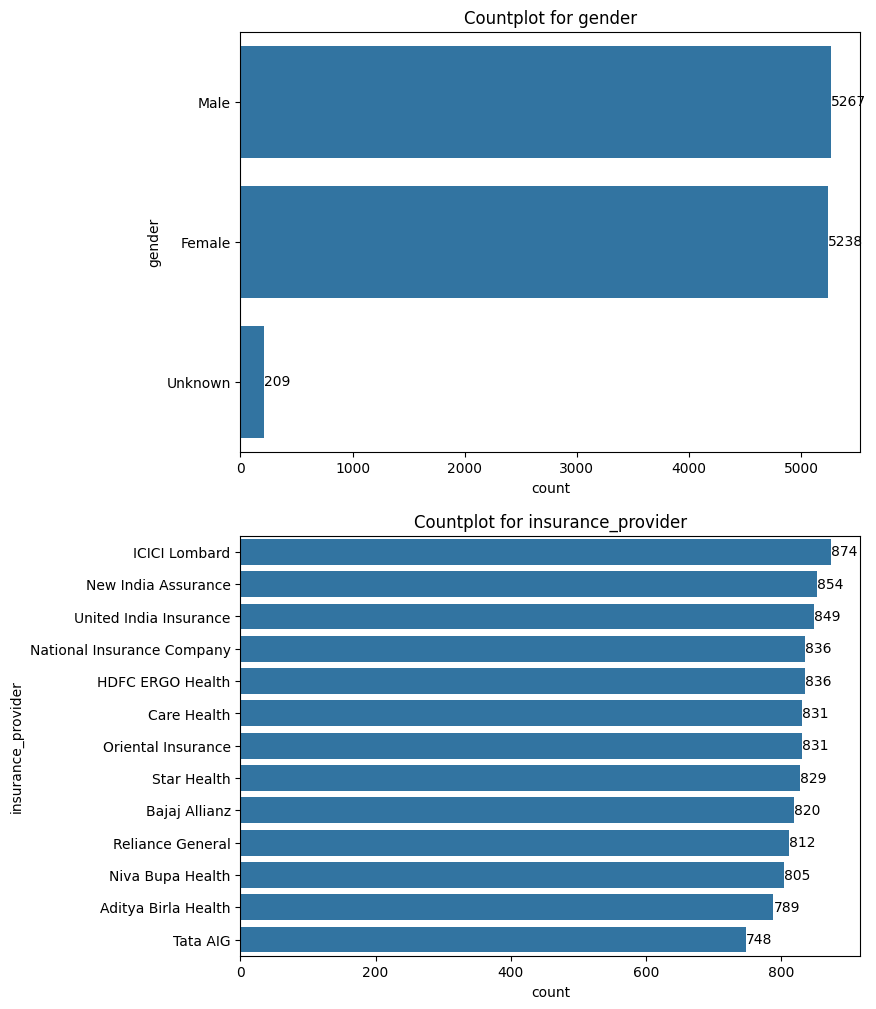

In [139]:
cols = cat_cols
plt.figure(figsize=(8,12))
for i in range(len(cols)):
    plt.subplot(2,1,i+1)
    order = df1[cols[i]].value_counts(ascending=False).index
    ax = sns.countplot(y=df1[cols[i]],order=order)
    ax.bar_label(ax.containers[0])
    plt.title(f'Countplot for {cols[i]}')
plt.show()

##### Inference -
1) Gender - The gender distribution is almost balanced, with 5267 male patients and 5238 female patients, while 209 records have gender marked as unknown.<br>
2) Insurance Provider - Most patients are covered by ICICI Lombard (874), New India Assurance (854), and United India Insurance (849), whereas Tata AIG has the least (748).
                   

##### Univariate Analysis - Numerical Columns

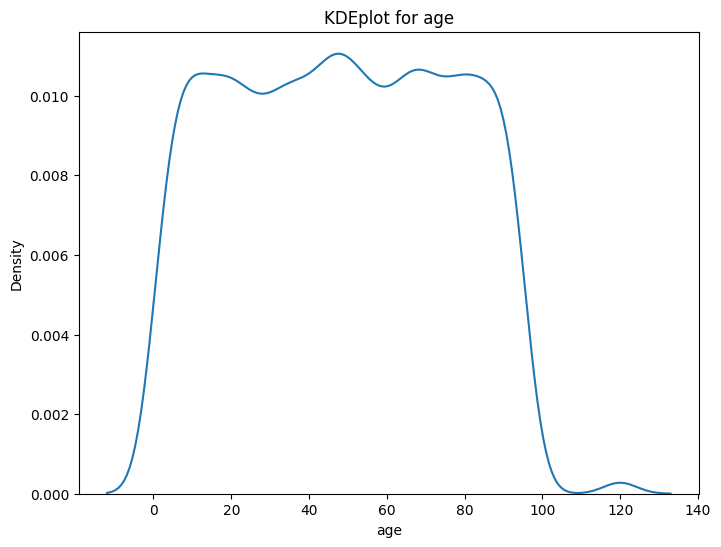

In [140]:
cols = num_cols
plt.figure(figsize=(8,6))
for i in range(len(cols)):
    plt.subplot(1,1,i+1)
    sns.kdeplot(x=df1[cols[i]])
    plt.title(f'KDEplot for {cols[i]}')
plt.show()    

##### Inference - 
- Age - Most patients are fall under the age range of 10 to 90 years, with a fairly even distribution in this interval, while very young (<10) and very old (>90) are comparatively fewer.

##### Bi-Variate Analysis (Categorical - Categorical)

In [141]:
cols = cat_cols
cols

['gender', 'insurance_provider']

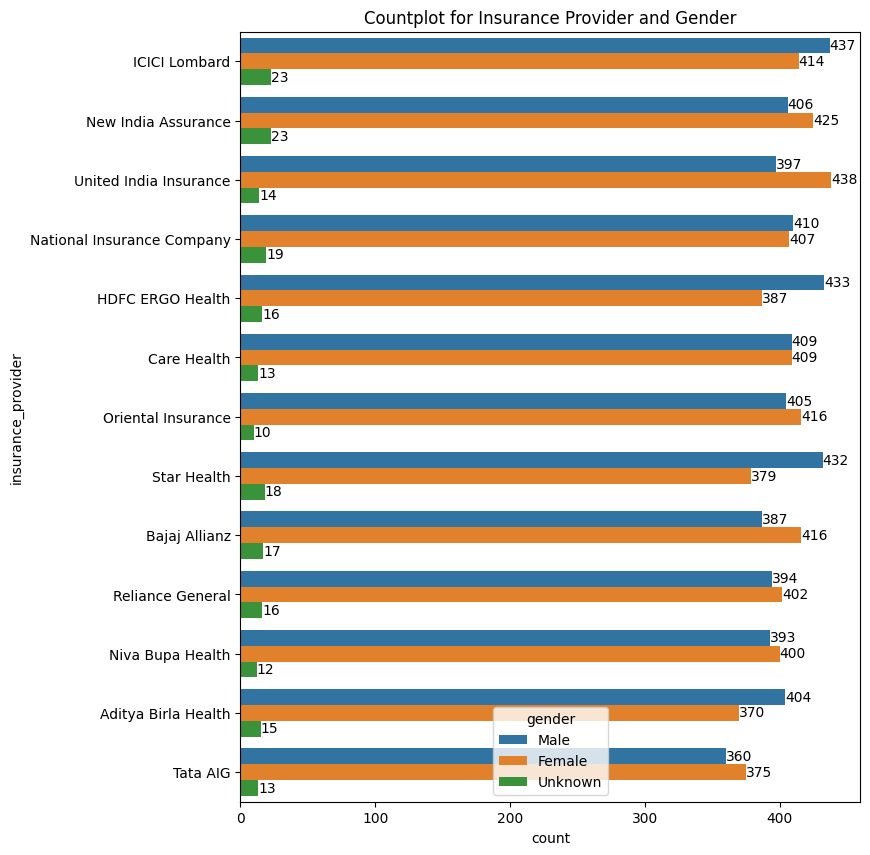

In [142]:
plt.figure(figsize=(8,10))
order = df1['insurance_provider'].value_counts().index
ax = sns.countplot(data=df1,y='insurance_provider',hue='gender',order=order)
for i in ax.containers:
    ax.bar_label(i)
plt.title('Countplot for Insurance Provider and Gender')
plt.show()

##### Inference -
- Insurance Provider and Gender - Insurance coverage appears fairly balanced across male and female patients across all providers, with only slight dominance of male patients in a few insurers.   

##### Bi-Variate Analysis (Categorical - Numerical)

In [143]:
print('Cat_Cols: ',cat_cols)
print('Num_Cols: ',num_cols)

Cat_Cols:  ['gender', 'insurance_provider']
Num_Cols:  ['age']


In [144]:
# sns.kdeplot(df1['age'])

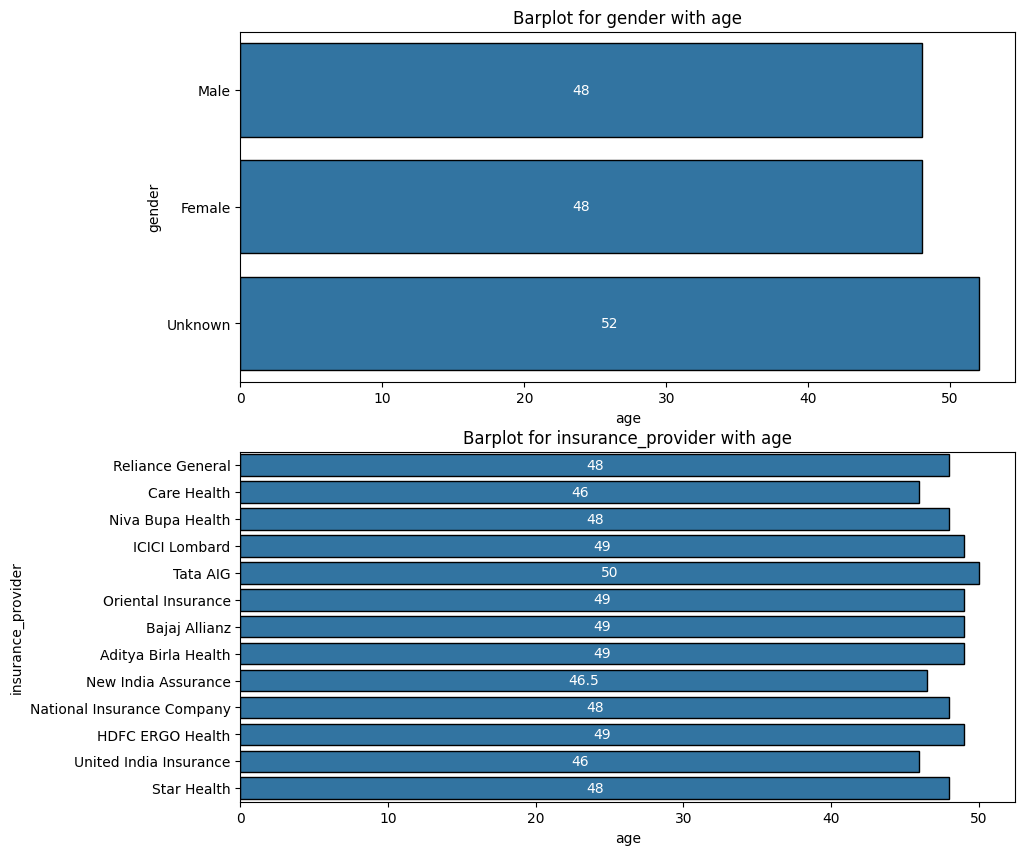

In [145]:
plt.figure(figsize=(10,10))
for i in range(len(cat_cols)):
        plt.subplot(2,1,i+1)
        ax = sns.barplot(data=df1,y=cat_cols[i],x='age',errorbar=('ci',0),estimator='median',edgecolor='black')
        for j in ax.containers:
            ax.bar_label(j,label_type='center',color='white')
        plt.title(f'Barplot for {cat_cols[i]} with age')
plt.show()        

##### Inference - 
1) Gender and Age - Median age is same for both Male and Female patients (48) , indicating a balanced age distribution across genders, while Unknown group shows slightly higher median age.
2) Insurance Provider and Age - Median age remains fairly consistent across all insurance providers (around 46--50 years), indicating no significant age-based variation in insurance usage among patients.  


#### 2) Doctors Table

In [146]:
cat_cols = df2.dtypes[df2.dtypes=='object'].index
num_cols = df2.dtypes[df2.dtypes!='object'].index
print('Cat_Cols',cat_cols)
print('Num_Cols',num_cols)

Cat_Cols Index(['doctor_id', 'fname', 'lname', 'specialization', 'contact_no', 'branch',
       'email'],
      dtype='object')
Num_Cols Index(['experience'], dtype='object')


In [147]:
cat_cols = df2[['specialization','branch']].columns
num_cols = num_cols
print('Cat_Cols: ',cat_cols)
print('Num_Cols: ',num_cols)

Cat_Cols:  Index(['specialization', 'branch'], dtype='object')
Num_Cols:  Index(['experience'], dtype='object')


##### Univariate Analysis - Categorical Columns

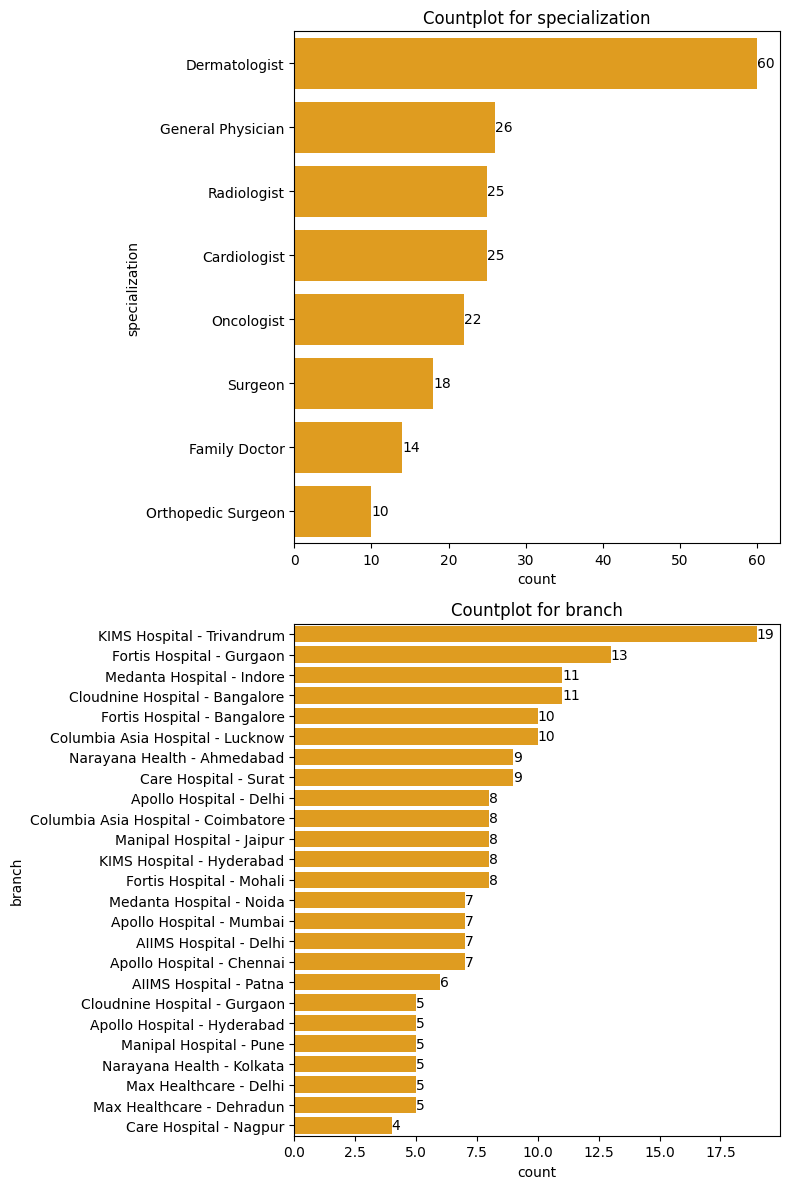

In [148]:
cols = cat_cols
plt.figure(figsize=(8,12))
 
for i in range(len(cols)):
    order = df2[cols[i]].value_counts().index
    plt.subplot(2,1,i+1)
    ax = sns.countplot(data=df2,y=df2[cols[i]],color='orange',order=order)
    ax.bar_label(ax.containers[0])
    plt.title(f'Countplot for {cols[i]}')
plt.tight_layout()
plt.show()    

##### Inference - 
1) Specialization - Dermatologists have the highest doctor count (60), followed by General Physicians (26) and Radiologists (25), whereas Orthopedic Surgeons and Family Doctors are comparatively fewer in number with 10 and 14 doctors respectively. 
2) Branch - Doctor availability varies across hospital branches , with locations such as KIMS Hospital Trivandrum having a higher concentration of doctors compared to other branches.

##### Univariate Analysis - Numerical Columns

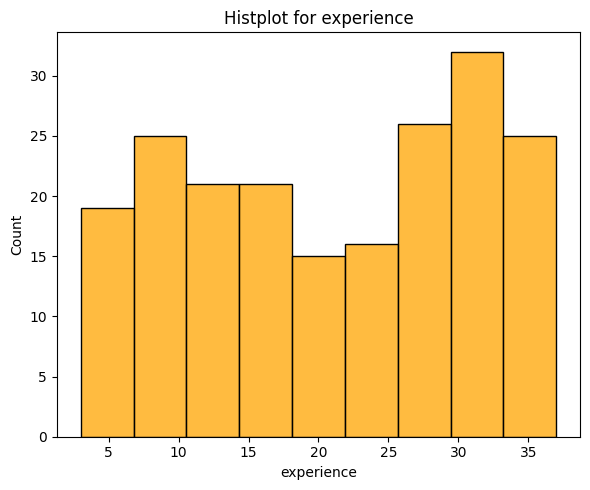

In [149]:
cols = num_cols
plt.figure(figsize=(6,5))
for i in range(len(cols)):
    plt.subplot(len(cols),1,i+1)
    sns.histplot(data=df2,x=cols[i],color='orange')
    plt.title(f'Histplot for {cols[i]}')
plt.tight_layout()
plt.show()


##### Inference - 
- Experience - Doctors experience ranges roughly between 3 and 37 years, with a higher concentration around mid-career doctors (8-12 years) experience and doctors with senior level experience (25-35 years).

##### Bi-Variate Analysis (Categorical - Categorical)

In [150]:
cat_cols

Index(['specialization', 'branch'], dtype='object')

In [151]:
cols = cat_cols
table = pd.crosstab(df2[cols[1]],df2[cols[0]])
# table

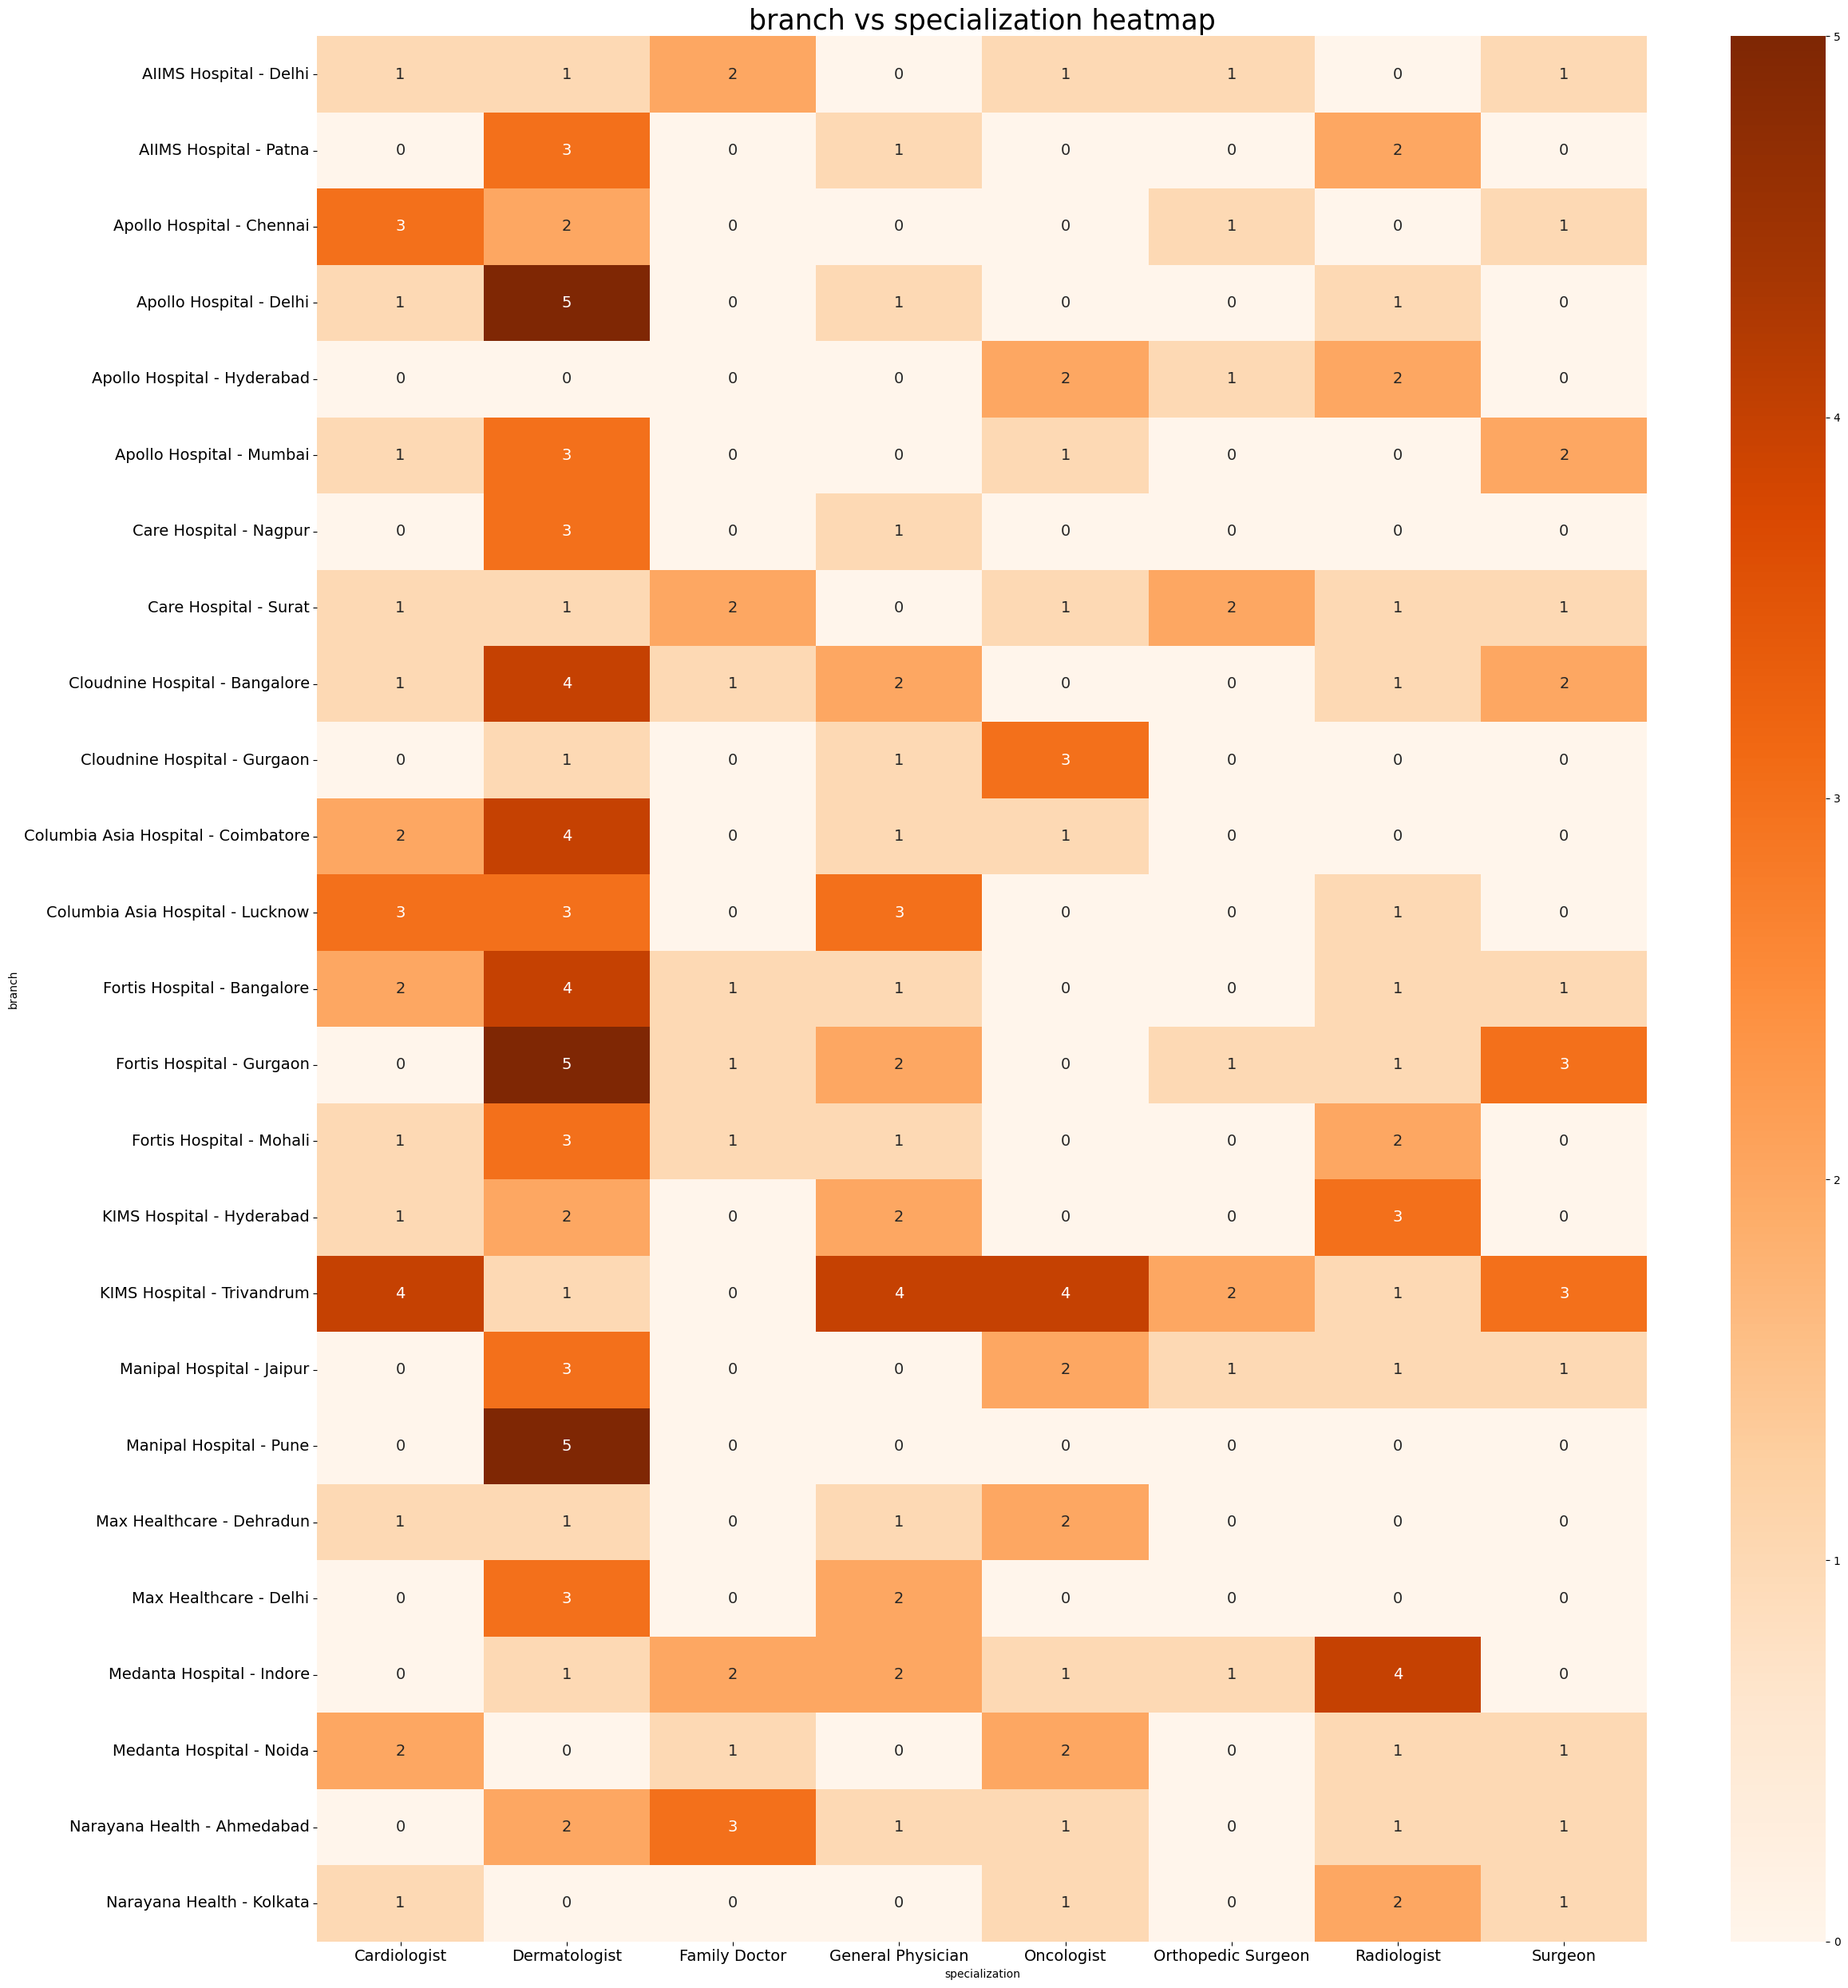

In [152]:
plt.figure(figsize=(25,25))
sns.heatmap(table,annot=True,cmap='Oranges',annot_kws={"size":14})
plt.title(f'{cols[1]} vs {cols[0]} heatmap',fontsize=25)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()
# Heatmap is used because both categorical variables have many categories, and it clearly shows distribution patterns between them.

##### Inference - 
- Branch and Specialization - The heatmap indicates variation in specialization distribution across various hospital branches, with some branches hosting a higher number of certain specialists compared to other. 

##### Bi-Variate Analysis (Categorical - Numerical)

In [153]:
print('Cat_Cols: ',cat_cols)
print('Num_Cols: ',num_cols)

Cat_Cols:  Index(['specialization', 'branch'], dtype='object')
Num_Cols:  Index(['experience'], dtype='object')


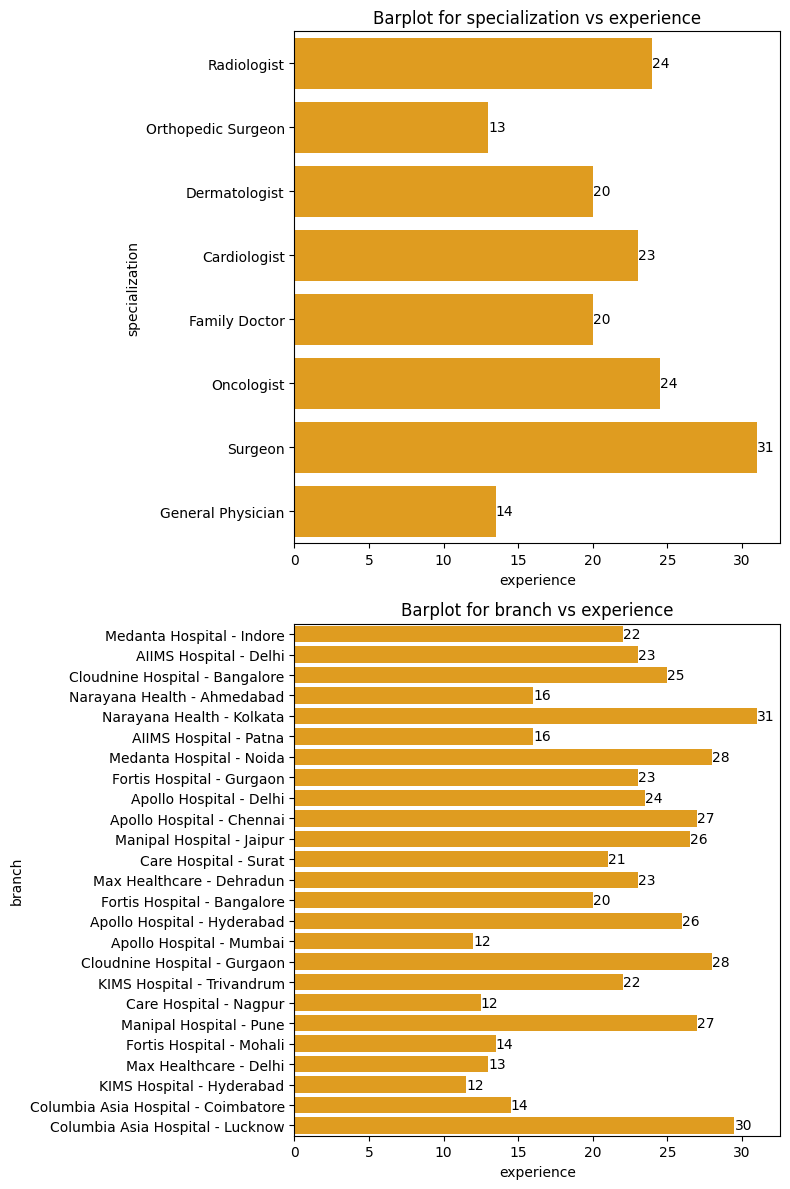

In [154]:
plt.figure(figsize=(8,12))
for i in range(len(cat_cols)):
    plt.subplot(len(cat_cols),1,i+1)
    ax = sns.barplot(data=df2,y=cat_cols[i],x='experience',color='orange',errorbar=('ci',0),estimator=np.median)
    ax.bar_label(ax.containers[0],fmt='%.0f')
    plt.title(f'Barplot for {cat_cols[i]} vs experience')
plt.tight_layout()
plt.show()    

##### Inference -
1) Specialization and Experience - Surgeons have the highest median experience followed by Radiologists and Oncologists, whereas Orthopedic Surgeons and General Physians exhibit comparatively lower median experience levels.
2) Median doctor experience varies across branches, with hospitals like Narayana Health (Kolkata) and Columbia Asia Hospital (Lucknow) having more experienced doctors, while a few branches show relatively lower experience levels.

#### 3) Billing Table

In [155]:
df3.columns

Index(['bill_id', 'patient_id', 'treatment_id', 'amount', 'payment_method',
       'payment_status', 'reason_for_visit', 'appointment_id', 'bill_date'],
      dtype='object')

In [156]:
cat_cols = df3.dtypes[df3.dtypes=='object'].index
num_cols = df3.dtypes[df3.dtypes!='object'].index
print('Cat_Cols: ',cat_cols)
print('Num_Cols: ',num_cols)

Cat_Cols:  Index(['bill_id', 'patient_id', 'treatment_id', 'payment_method',
       'payment_status', 'reason_for_visit', 'appointment_id'],
      dtype='object')
Num_Cols:  Index(['amount', 'bill_date'], dtype='object')


In [157]:
cat_cols = ['payment_method','payment_status','reason_for_visit']
num_cols = ['amount']
print('Cat_Cols: ',cat_cols)
print('Num_Cols: ',num_cols)

Cat_Cols:  ['payment_method', 'payment_status', 'reason_for_visit']
Num_Cols:  ['amount']


##### Univariate Analysis - Categorical Columns

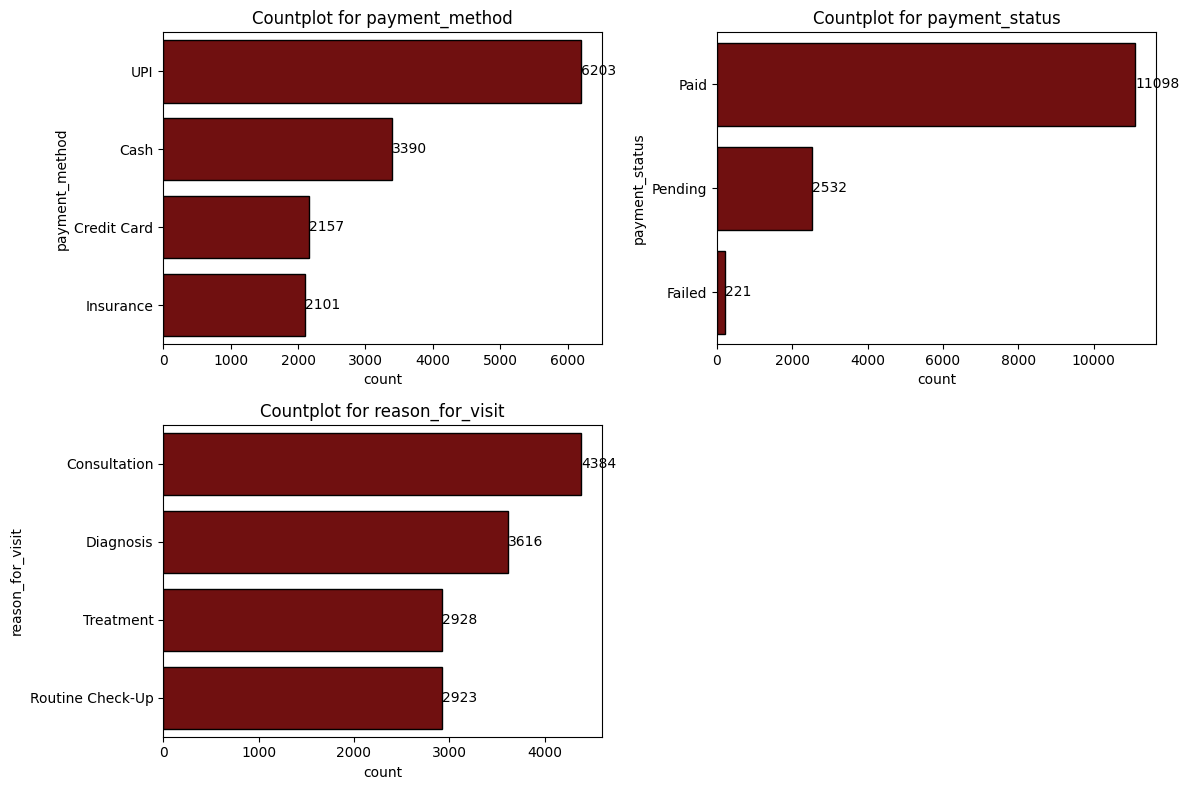

In [158]:
cols = cat_cols
plt.figure(figsize=(12,8))
for i in range(len(cols)):
    order = df3[cols[i]].value_counts().index
    plt.subplot(2,2,i+1)
    ax = sns.countplot(data=df3,y=cat_cols[i],color='maroon',edgecolor='black',order=order)
    for j in ax.containers:
        ax.bar_label(j)
    plt.title(f'Countplot for {cols[i]}')
plt.tight_layout()
plt.show()

##### Inference - 
1) Payment Method -  Most patients prefer UPI as the primary payment method, followed by cash, while credit cards and insurance based payments are comparatively lower.
2) Payment Status - A large majority payments are successfully completed, with a smaller portion pending and very minimal failed transactions.
3) Reason for visit - Most patients visit the hospital mainly for consultation and diagnosis, while comparatively fewer are for treatment and routine check-ups.

##### Univariate Analysis - Numerical Columns

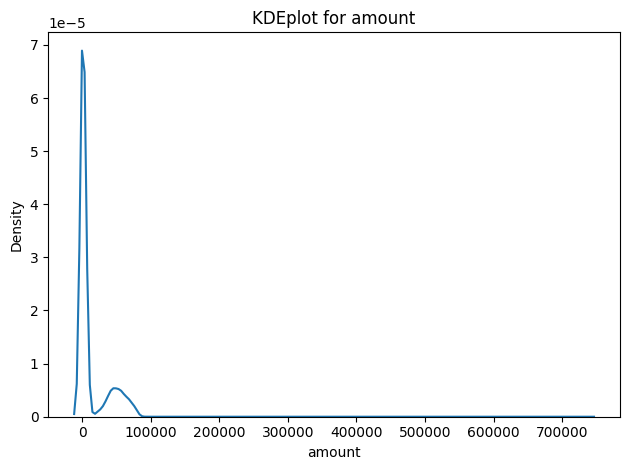

In [159]:
cols = num_cols
for i in range(len(cols)):
    plt.subplot(len(cols),1,i+1)
    sns.kdeplot(data=df3,x=cols[i])
    plt.title(f'KDEplot for {cols[i]}')
plt.tight_layout()    
plt.show()

##### Inference - 
- Billing - The billing amount distribution is highly right-skewed, indicating the most patients incur relatively low to moderate charges, while only few cases involve very high billing amount. 

##### Bi-Variate Analysis (Categorical - Categorical)

In [160]:
print('Cat_cols: ',cat_cols)
print('Num_cols: ',num_cols)

Cat_cols:  ['payment_method', 'payment_status', 'reason_for_visit']
Num_cols:  ['amount']


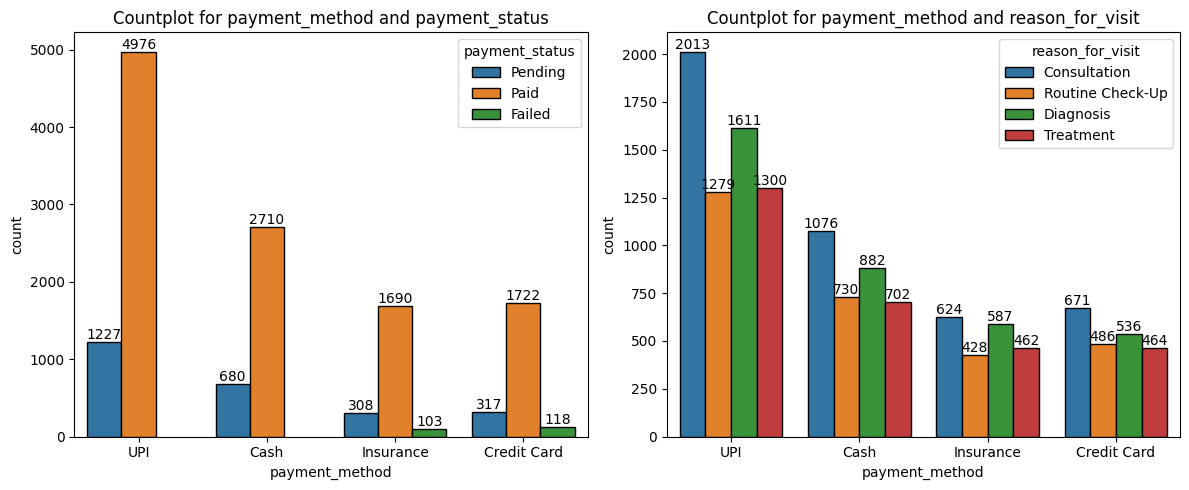

In [161]:
# Selecting these pairs as they can provide meaningful operational insight.
pairs = [('payment_method','payment_status'),('payment_method','reason_for_visit')]
plt.figure(figsize=(12,5))
for i in range(len(pairs)):
    plt.subplot(1,2,i+1)
    ax = sns.countplot(data=df3,x=pairs[i][0],hue=pairs[i][1],edgecolor='black')
    for j in ax.containers:
        ax.bar_label(j)
    plt.title(f'Countplot for {pairs[i][0]} and {pairs[i][1]}')
plt.tight_layout()
plt.show()

##### Inference - 
1) Payment Method and Payment Status - Most payments made through UPI, Cash, Insurance and Credit Card are successfully paid, with pending and failed transactions being very few across all payment methods.
2) Payment Method and Reason for Visit - UPI is the most commonly used payment method across all visit types, followed by cash, while insurance and credit card payments are comparatively lower for every reason for visit. 

##### Bi-Variate Analysis (Categorical - Numerical)

In [162]:
print('Cat_cols: ',cat_cols)
print('Num_cols: ',num_cols)

Cat_cols:  ['payment_method', 'payment_status', 'reason_for_visit']
Num_cols:  ['amount']


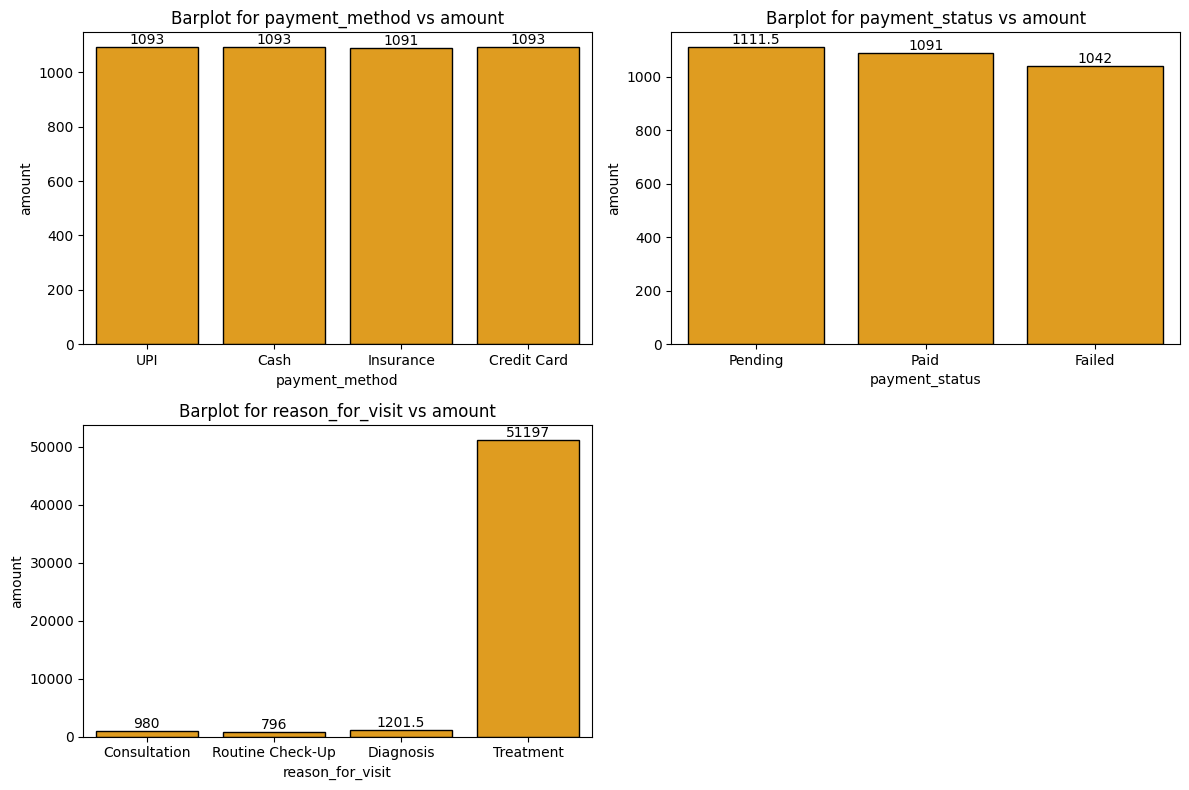

In [163]:
plt.figure(figsize=(12,8))
for i in range(len(cat_cols)):
    plt.subplot(2,2,i+1)
    ax = sns.barplot(data=df3,x=cat_cols[i],y='amount',edgecolor='black',errorbar=None,color='orange',estimator=np.median)
    for j in ax.containers:
        ax.bar_label(j)
    plt.title(f'Barplot for {cat_cols[i]} vs amount')
plt.tight_layout()
plt.show()

##### Inference - 
1) Payment Method and Amount - The median billing amount is almost similar across all payment methods, indicating that the choice of payment mode does not significantly impact the bill value.
2) Payment Status and Amount - Pending payments have a slightly higher median amount compared to paid and failed payments, suggesting higher bills are more likely to remain unpaid.
1) Reason for Visit and Amount - Treatment related visits have a significantly higher billing amount compared to consultation, diagnosis and routine check-ups, indicating the major costs are driven by treatment procedures.

#### 4) Appointments Table

In [164]:
df4.columns

Index(['ap_id', 'patient_id', 'doctor_id', 'ap_time', 'reason_for_visit',
       'status', 'ap_date'],
      dtype='object')

In [165]:
cat_cols = df4.dtypes[df4.dtypes=='object'].index
num_cols = df4.dtypes[df4.dtypes!='object'].index
print('Cat_Cols: ',cat_cols)
print('Num_Cols: ',num_cols)

Cat_Cols:  Index(['ap_id', 'patient_id', 'doctor_id', 'reason_for_visit', 'status'], dtype='object')
Num_Cols:  Index(['ap_time', 'ap_date'], dtype='object')


In [166]:
cat_cols = ['reason_for_visit','status']
print('Cat_Cols',cat_cols)
# No numerical columns present in this table for numerical EDA.

Cat_Cols ['reason_for_visit', 'status']


##### Univariate Analysis - Categorical Columns

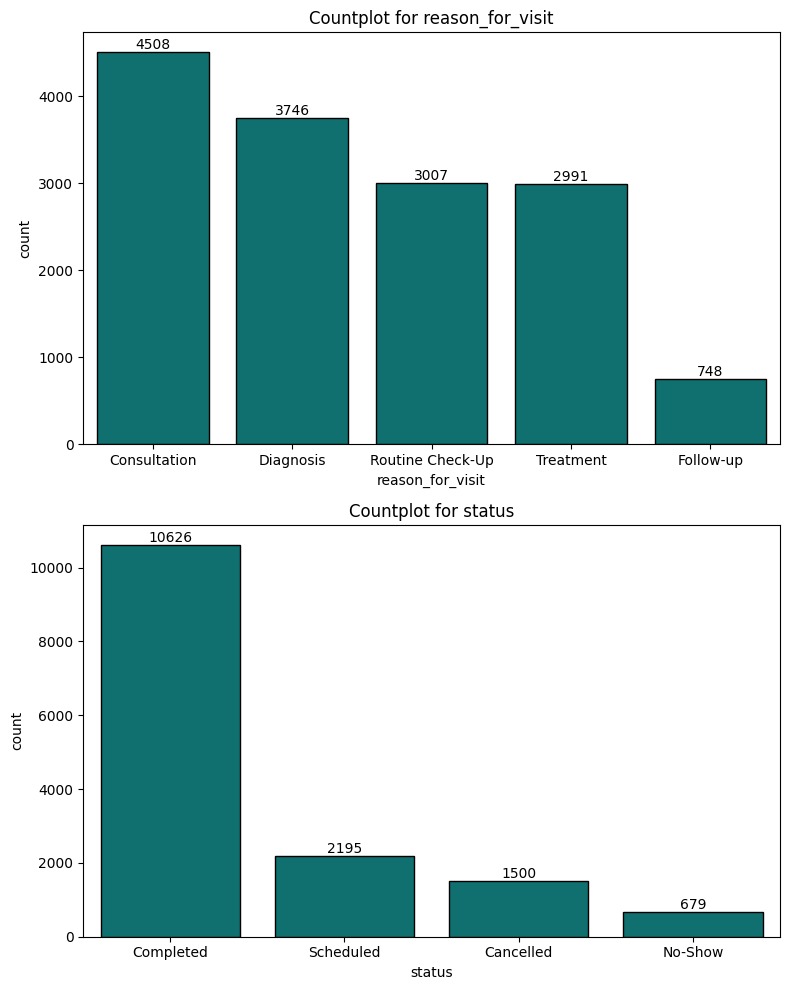

In [167]:
cols = cat_cols
plt.figure(figsize=(8,10))
for i in range(len(cols)):
    order = df4[cols[i]].value_counts(ascending=False).index
    plt.subplot(2,1,i+1)
    ax = sns.countplot(data=df4,x=cols[i],color='teal',edgecolor='black',order=order)
    for j in ax.containers:
        ax.bar_label(j)
    plt.title(f'Countplot for {cols[i]}')
plt.tight_layout()
plt.show()

##### Inference - 
1) Reason for Visit - Consultation is the most common reason for appointment with 4500 appointments, followed by Diagnosis with 3737 appointments, while Follow-up visits are comparatively much lower.
2) Status - Most appointments are successfully completed, whereas only a small portion remain scheduled, cancelled , or results in no-show, indicating an overall stable appointment completion rate.

##### Bi-Variate Analysis - (Categorical - Categorical)

In [168]:
df4['reason_for_visit'].value_counts()

reason_for_visit
Consultation        4508
Diagnosis           3746
Routine Check-Up    3007
Treatment           2991
Follow-up            748
Name: count, dtype: int64

In [169]:
df4['status'].value_counts()

status
Completed    10626
Scheduled     2195
Cancelled     1500
No-Show        679
Name: count, dtype: int64

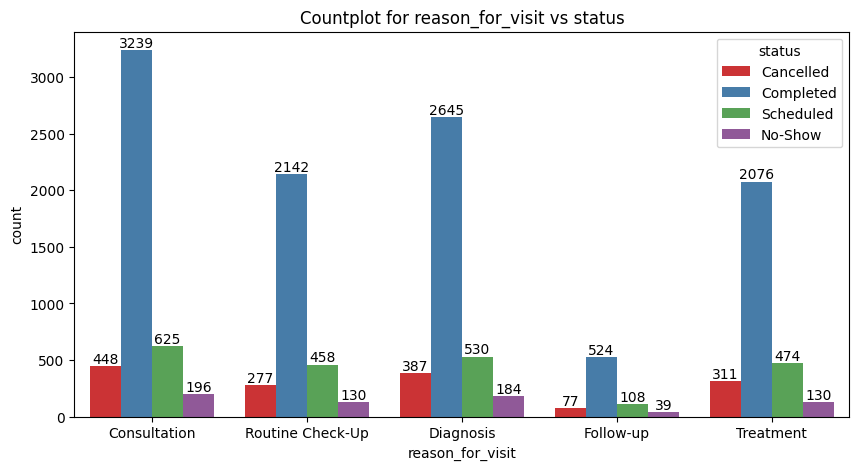

In [170]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df4,x='reason_for_visit',hue='status',palette='Set1')
for i in ax.containers:
    ax.bar_label(i)
plt.title(f'Countplot for reason_for_visit vs status')
plt.show()
# Countplot is preferred over heatmap here as it is clearly shows category wise counts for a small number of categories.

##### Inference-
- Reason for visit and Status - Most appintments are successfully completed across all visit types, with consultation and diagnosis having highest completion counts, while cancellations and no-shows remain comparatively low among all other categories.

#### 5) Treatment Table

In [171]:
df5.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T0001,A00006,MRI Scan,Brain Imaging,4573.0,2025-05-28
1,T0002,A00010,MRI Scan,Brain Imaging,5035.0,2023-09-13
2,T0003,A00016,Appendectomy,Appendix Removal,50950.0,2025-06-16
3,T0004,A00019,ECG,Heart Analysis,434.0,2024-12-12
4,T0005,A00020,Appendectomy,Appendix Removal,45367.0,2025-02-04


In [172]:
cat_cols = df5.dtypes[df5.dtypes=='object'].index
num_cols = df5.dtypes[df5.dtypes!='object'].index
print('Cat_cols:\n',cat_cols)
print('Num_cols:\n',num_cols)

Cat_cols:
 Index(['treatment_id', 'appointment_id', 'treatment_type', 'description'], dtype='object')
Num_cols:
 Index(['cost', 'treatment_date'], dtype='object')


In [173]:
df5['treatment_type'].unique()

array(['MRI Scan', 'Appendectomy', 'ECG', 'Radiation Therapy',
       'Hernia Repair', 'Chemotherapy', 'CT Scan', 'Stress Test', 'X-Ray'],
      dtype=object)

In [174]:
cat_cols = ['treatment_type','description']
num_cols = ['cost']

##### Univariate Analysis - Categorical Columns

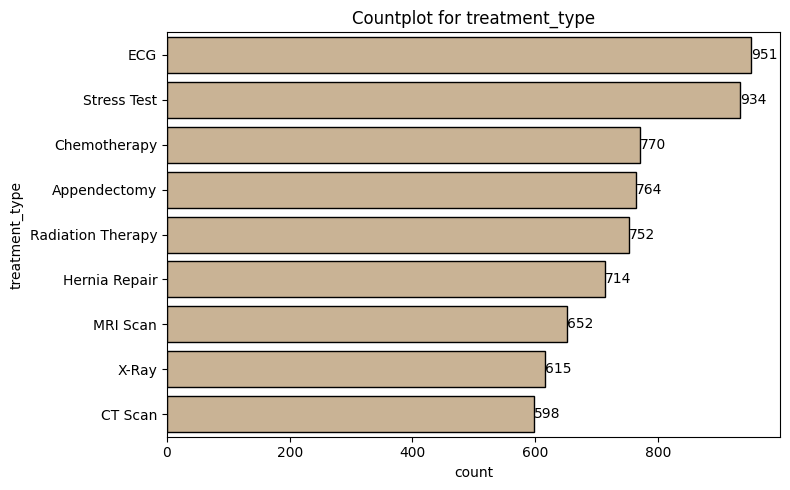

In [175]:
plt.figure(figsize=(8,5))
order = df5['treatment_type'].value_counts(ascending=False).index
ax = sns.countplot(data=df5,y='treatment_type',edgecolor='black',color='tan',order=order)
for j in ax.containers:
    ax.bar_label(j)
plt.title(f'Countplot for treatment_type')
plt.tight_layout()
plt.show()
# Using treatment_type for categorical univariate analysis because description is dependent on it, so analyzing both would repeat the same pattern.

##### Inference -
- Treatment Type - ECG and Stress Test are the most frequently performed treatments, followed by Chemotherapy and Appendectomy, while CT Scan and X-Ray are comparatively less frequent.

##### Univariate Analysis - Numerical Columns

In [176]:
num_cols

['cost']

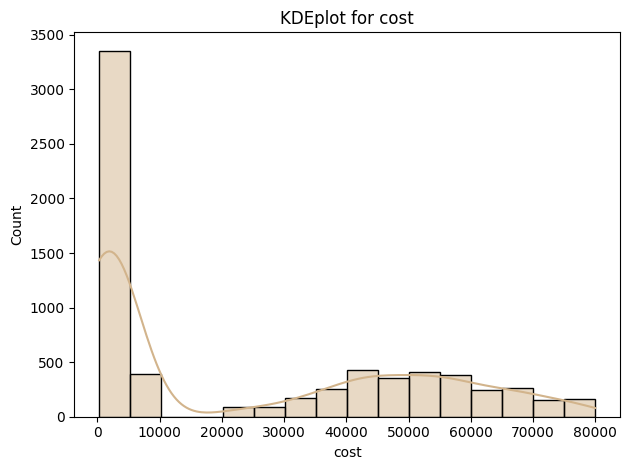

In [177]:
cols = num_cols
for i in range(len(cols)):
    sns.histplot(data=df5,x=cols[i],kde=True,color='tan')
    plt.title(f'KDEplot for {cols[i]}')
plt.tight_layout()
plt.show()

##### Inference - 
- Cost - Most treatments fall in lower cost range, while a small number of procedures are much more expensive, showing a clear right-skew in cost distribution. 

##### Skipping categroical - categorical bi-variate analysis because the available categorical columns (tretament_type and description) are dependent and would give redundant insights. 

##### Bi-Variate Analysis (Categorical - Numerical)

In [178]:
cat_cols.remove('description')
print('Cat_Cols\n',cat_cols)
print('Num_Cols\n',num_cols)
# Using treatment_type vs cost for Cat–Num analysis, since description is already dependent on treatment_type and would provide redundant insights.

Cat_Cols
 ['treatment_type']
Num_Cols
 ['cost']


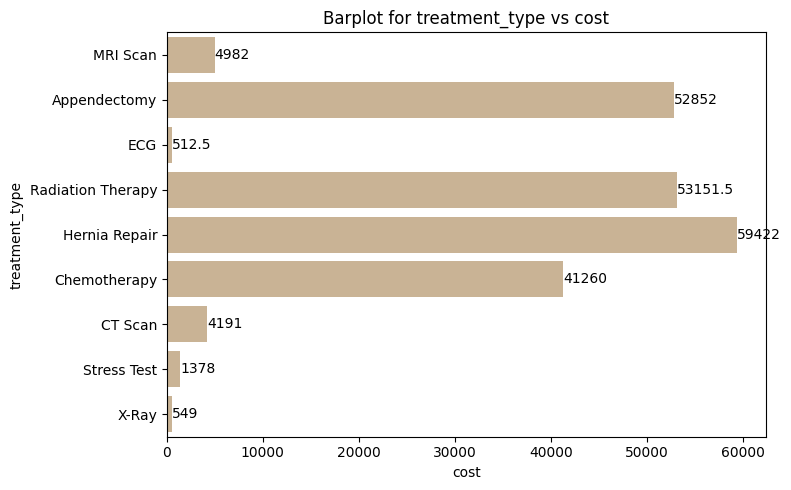

In [179]:
plt.figure(figsize=(8,5))
for i in range(len(cat_cols)):
    plt.subplot(len(cat_cols),1,i+1)
    ax = sns.barplot(df5,y=cat_cols[i],x='cost',estimator=np.median,errorbar=None,color='tan')
    for j in ax.containers:
        ax.bar_label(j)
    plt.title(f'Barplot for {cat_cols[i]} vs cost')
plt.tight_layout()
plt.show()
# Using median as a estimator because cost column is right skewed.

##### Inference - 
- Treatment_type and Cost - Major surgeries like Hernia Repair, Radiation Therapy and Appenectomy costs the most, while tests like ECG, X-Ray and Stress Test are the cheapest. 

### Business KPIs & Analytical Insights

#### 1) Patients Centric Analysis

##### KPIs

In [180]:
Total_Patients = df1['patient_id'].nunique()
Average_Age = round(df1['age'].median())
Male_Patients = df1[df1['gender']=='Male'].shape[0]
Male_P_Percentage = str(round((Male_Patients / Total_Patients)*100,2)) + '%'
Female_Patients = df1[df1['gender']=='Female'].shape[0]
Female_P_Percentage = str(round((Female_Patients / Total_Patients)*100,2)) + '%'

In [181]:
Max_Year = df1['reg_date'].dt.year.max()
Max_Month = df1['reg_date'][df1['reg_date'].dt.year==df1['reg_date'].dt.year.max()].dt.month.max()

Curr_Month_New_Patients = df1['patient_id'][(df1['reg_date'].dt.month==Max_Month) & (df1['reg_date'].dt.year==Max_Year)].nunique()

In [182]:
kpi = {'Total_Patients':Total_Patients,'Average_Patient_Age':Average_Age,
          'Male_Patients_%':Male_P_Percentage,'Female_Patients_%':Female_P_Percentage,'New_Patients (Current Month)':Curr_Month_New_Patients}
kpi_df = pd.DataFrame({'KPIs':list(kpi.keys()), 'Values':list(kpi.values())}).style.hide(axis='index')
kpi_df

KPIs,Values
Total_Patients,10714
Average_Patient_Age,48
Male_Patients_%,49.16%
Female_Patients_%,48.89%
New_Patients (Current Month),204


##### Insights

##### 1) Monthly Patient Registration Trend

In [183]:
# Extracting Year, Month and Month_Name columns in patients table.
df1['reg_year'] = df1['reg_date'].dt.year
df1['reg_month'] = df1['reg_date'].dt.month
df1['reg_month_name'] = df1['reg_date'].dt.month_name()

In [184]:
# Creating variable 'samp' for extracting those rows in which reg_date is null.
samp = df1[~df1['reg_date'].isnull()]
samp['year_month'] = samp['reg_date'].dt.to_period('M').dt.strftime('%b %Y')

In [185]:
res = samp.groupby(['reg_year','reg_month','year_month'])['patient_id'].count().reset_index()
res = res.sort_values(['reg_year','reg_month'],ascending=[True,True])
res = res[['year_month','patient_id']]
res.columns = ['Year_Month','Registered_Patients']
res.set_index('Year_Month',inplace=True)
res

,Registered_Patients
Year_Month,
Jan 2021,200
Feb 2021,175
Mar 2021,179
Apr 2021,164
May 2021,185
Jun 2021,191
Jul 2021,199
Aug 2021,188
Sep 2021,175


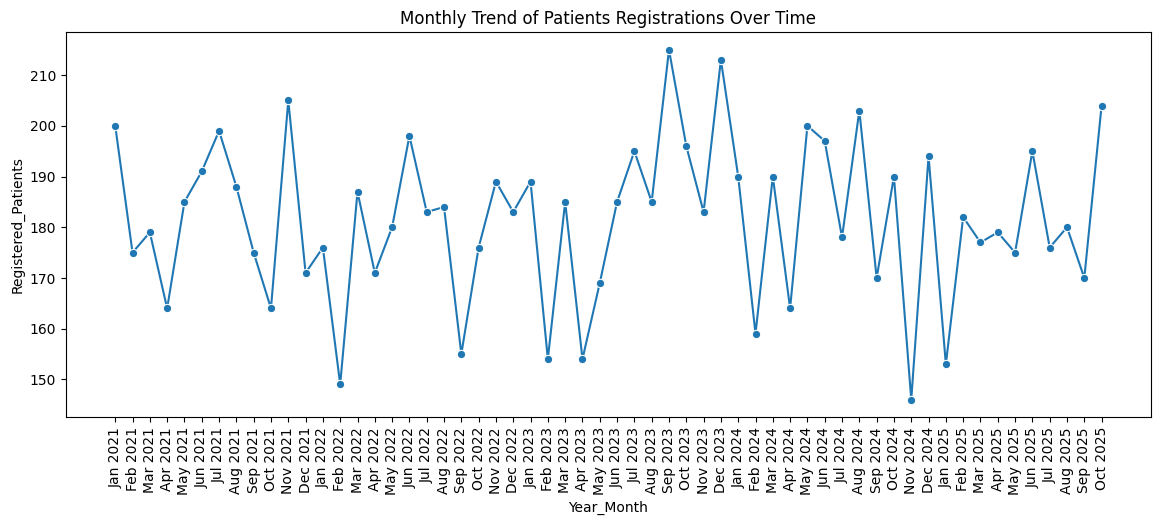

In [186]:
plt.figure(figsize=(14,5))
sns.lineplot(data=res,x='Year_Month',y='Registered_Patients',marker='o')
plt.title(f'Monthly Trend of Patients Registrations Over Time')
plt.xticks(rotation=90)
plt.show()

###### Inference - Patient registrations fluctuates between 150 to 215 per month, with an average of around 180+ patients monthly, indicating a stable and consistent patient inflow over the years.

##### 2) Patients age group  wise revenue contribution

In [187]:
samp = pd.merge(df1,df3,on='patient_id',how='inner')[['age','amount']]
samp['age'] = pd.to_numeric(samp['age']).astype('int')

# Making age groups
def age_groups(age):
    if age >=0 and age<=10:
        return 'Children'
    elif age>=11 and age<=20:
        return 'Teens'
    elif age>=21 and age<=40:
        return 'Young Adults'
    elif age>=41 and age<=60:
        return 'Middle Age Adults'
    elif age>=61:
        return 'Senior'    
samp['age_group'] = samp['age'].apply(age_groups)    

In [188]:
res = samp.groupby('age_group')['amount'].sum().reset_index()
res.columns = ['Age_Group','Revenue']
res['Total_Revenue'] = res['Revenue'].sum()
res['Revenue_Contribution'] = round((res['Revenue'] / res['Total_Revenue'])*100,2).astype(str) +'%'
res['Revenue_Contribution_Num'] = round((res['Revenue'] / res['Total_Revenue'])*100,2)
res.sort_values('Revenue_Contribution_Num',ascending=False,inplace=True)
final_res = res[['Age_Group','Revenue_Contribution']]
final_res

,Age_Group,Revenue_Contribution
2,Senior,38.19%
1,Middle Age Adults,22.41%
4,Young Adults,19.28%
3,Teens,10.53%
0,Children,9.59%


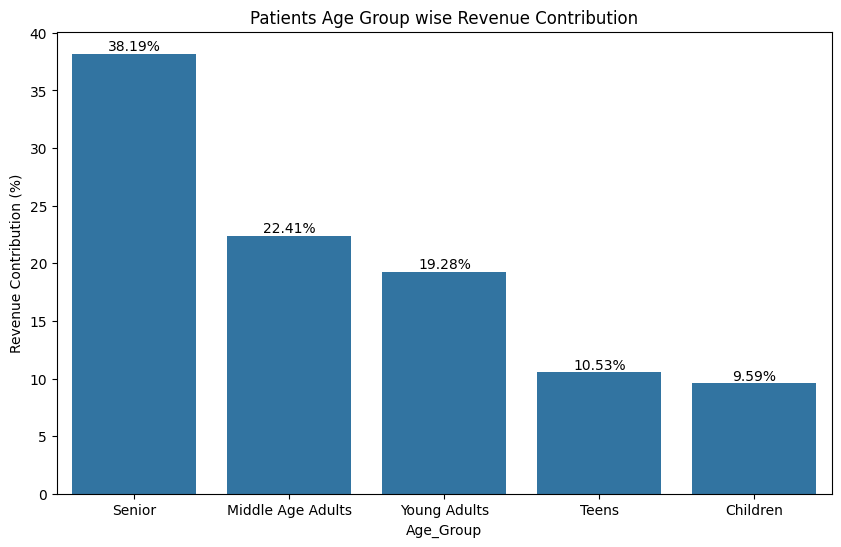

In [189]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=res,x='Age_Group',y='Revenue_Contribution_Num')
ax.bar_label(ax.containers[0],fmt='%.2f%%')
plt.title('Patients Age Group wise Revenue Contribution')
plt.ylabel('Revenue Contribution (%)')
plt.show()

###### Inference - Seniors contribute the highest share of revenue (38.19%), followed by Middle Age Adults (22.41%) and Young_Adults(19.28%), indicating revenue is primarily driven by older patients.

##### 3) Top 5 Cities by Revenue, Contribution %, Patients & Revenue per Patient

In [190]:
df1['address'][df1['address']=='Not Available'].shape

(214,)

In [191]:
# Extracting city from address column in patients table. 
df1['city'] = [i.split(',')[-2] if i!='Not Available' else i for i in df1['address']]

In [192]:
samp = pd.merge(df1,df3,on='patient_id',how='inner')
samp = samp[samp['city']!='Not Available']
samp.shape

(13580, 24)

In [193]:
res = samp.groupby('city').agg({'patient_id':'count','amount':'sum'})
res.columns = ['Patients_Count','Revenue']
res['Total_Revenue'] = res['Revenue'].sum()
res['Revenue_Contribution'] = round((res['Revenue'] / res['Total_Revenue'])*100,2).astype(str) + '%'
res['Revenue_per_Patient'] = round((res['Revenue'] / res['Patients_Count']),2)
res.sort_values('Revenue',ascending=False,inplace=True)
res = res.head(5)
res

,Patients_Count,Revenue,Total_Revenue,Revenue_Contribution,Revenue_per_Patient
city,,,,,
Hyderabad,550,8701143.0,168621755.0,5.16%,15820.26
Pune,554,7891257.0,168621755.0,4.68%,14244.15
Ghaziabad,551,7757535.0,168621755.0,4.6%,14079.01
Nashik,575,7719332.0,168621755.0,4.58%,13424.93
Delhi,589,7675915.0,168621755.0,4.55%,13032.11


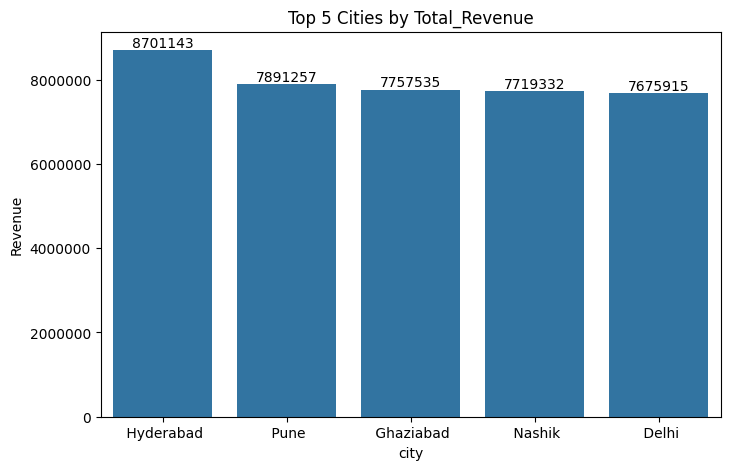

In [194]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=res,x=res.index,y=res['Revenue'])
ax.bar_label(ax.containers[0],fmt='%.0f')
plt.title(f'Top 5 Cities by Total_Revenue')
plt.ticklabel_format(style='plain',axis='y')
plt.show()

In [195]:
###### Inference - Hyderabad city generates the highest revenue among the top five cities, followed by Pune and Ghaziabad,
# making these cities the key revenue drivers.

##### 4) Patients Retention and Visit Frequency

In [196]:
samp = pd.merge(df1,df4,on='patient_id',how='inner')
# samp.head()

In [197]:
samp_df = samp.groupby('patient_id')['ap_id'].count().reset_index()
samp_df['patient_type'] = np.where(samp_df['ap_id']>1,'repeat_patient','one-time patient')
samp_df.head()

,patient_id,ap_id,patient_type
0,P00001,1,one-time patient
1,P00002,1,one-time patient
2,P00003,1,one-time patient
3,P00004,1,one-time patient
4,P00005,1,one-time patient


In [198]:
tp = samp_df['patient_id'].nunique()
tv = samp_df['ap_id'].sum()
otp = samp_df['patient_id'][samp_df['patient_type']=='one-time patient'].shape[0]
rp = samp_df['patient_id'][samp_df['patient_type']=='repeat_patient'].shape[0]
otp_percentage = str(round((otp / tp)*100,2)) + '%'
rp_percentage = str(round((rp / tp)*100,2)) + '%'
av = round((tv / tp),2)

In [199]:
res = pd.DataFrame({'Metric':['Total Patients','Total Visits','Average Visits','One-Time Patients',
                              'One-Time Patients Percentage','Repeat Patients','Repeat Patients Percentage'],
                   'Value':[tp,tv,av,otp,otp_percentage,rp,rp_percentage]}).set_index('Metric')
res

,Value
Metric,
Total Patients,10714
Total Visits,15000
Average Visits,1.4
One-Time Patients,7501
One-Time Patients Percentage,70.01%
Repeat Patients,3213
Repeat Patients Percentage,29.99%


In [200]:
pie_val = samp_df['patient_type'].value_counts()
pie_val

patient_type
one-time patient    7501
repeat_patient      3213
Name: count, dtype: int64

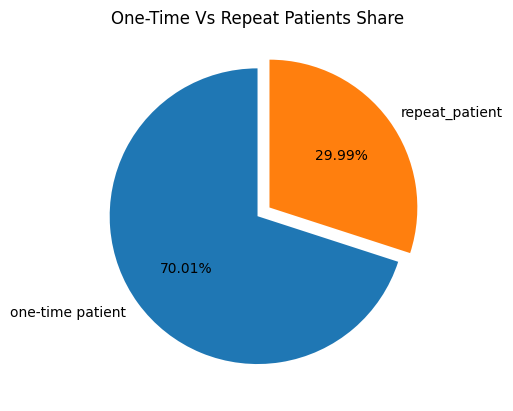

In [201]:
plt.pie(x=pie_val.values,labels=pie_val.index,autopct='%.2f%%',explode=[0,0.1],startangle=90)
plt.title(f'One-Time Vs Repeat Patients Share')
plt.show()

In [202]:
df4.columns

Index(['ap_id', 'patient_id', 'doctor_id', 'ap_time', 'reason_for_visit',
       'status', 'ap_date'],
      dtype='object')

In [203]:
df1.head()

,patient_id,first_name,last_name,gender,age,contact_no,address,insurance_provider,insurance_no,email,dob,reg_date,reg_year,reg_month,reg_month_name,city
0,P00001,Amit Vijay,Ahluwalia,Male,18.0,+91 7115038051,"249, Main Street, Kolkata, Uttar Pradesh - 674153",Reliance General,RG-24209404,amitvijay.ahluwalia.p00001@hotmail.com,2007-01-06,2025-01-09,2025.0,1.0,January,Kolkata
1,P00002,Vikas Vijay,Jain,Male,85.0,+91 9145843348,"84, Ring Road, Kanpur, Uttar Pradesh - 410362",Care Health,CH-32750375,vikasvijay.jain.p00002@proton.me,1940-09-06,2024-06-09,2024.0,6.0,June,Kanpur
2,P00003,Raj Raj,Chavan,Male,92.0,+91 6478975878,"23, Main Street, Hyderabad, Bihar - 347731",Niva Bupa Health,NBH-12508327,rajraj.chavan.p00003@gmail.com,1933-08-05,2025-06-30,2025.0,6.0,June,Hyderabad
3,P00004,Charvi Kumari,Chavan,Female,37.0,+91 7710752589,"231, Main Street, Noida, Madhya Pradesh - 593124",Reliance General,RG-39882806,charvikumari.chavan.p00004@proton.me,1988-01-20,2022-07-12,2022.0,7.0,July,Noida
4,P00005,Sara Kumari,Mishra,Female,92.0,+91 9348932868,"203, MG Road, Delhi, Uttar Pradesh - 119295",ICICI Lombard,IL-58438440,sarakumari.mishra.p00005@proton.me,1933-11-28,2022-10-16,2022.0,10.0,October,Delhi


##### 5) Cumulative Patient Base Growth + MoM% Trend

In [204]:
df = df1[~df1['reg_date'].isnull()]

samp = df.groupby(['reg_year','reg_month','reg_month_name',])['patient_id'].count().reset_index()
samp['reg_year'] = pd.to_numeric(samp['reg_year']).astype('int64') 
samp.sort_values(['reg_year','reg_month'],ascending=[True,True],inplace=True)
samp = samp[['reg_year','reg_month_name','patient_id']]
samp.columns = ['Year','Month','Curr_Month_Patients_Count']
samp['Month'] = samp['Month'].str[:3]
samp['Month_Year'] =  samp['Month'].astype(str) + ' ' + samp['Year'].astype(str)
samp['Prev_Month_Patients_Count'] = samp['Curr_Month_Patients_Count'].shift(1).fillna(0).astype(int)
samp['Running_Patients_Count'] = samp['Curr_Month_Patients_Count'].cumsum()
samp['MOM%_Change'] = (((samp['Curr_Month_Patients_Count'] - samp['Prev_Month_Patients_Count']) /
                      samp['Prev_Month_Patients_Count'])*100).replace(np.inf,0).round(2)
samp = samp[['Month_Year','Curr_Month_Patients_Count','Prev_Month_Patients_Count','Running_Patients_Count','MOM%_Change']]
samp.set_index('Month_Year',inplace=True)
samp

,Curr_Month_Patients_Count,Prev_Month_Patients_Count,Running_Patients_Count,MOM%_Change
Month_Year,,,,
Jan 2021,200,0,200,0.00
Feb 2021,175,200,375,-12.50
Mar 2021,179,175,554,2.29
Apr 2021,164,179,718,-8.38
May 2021,185,164,903,12.80
Jun 2021,191,185,1094,3.24
Jul 2021,199,191,1293,4.19
Aug 2021,188,199,1481,-5.53
Sep 2021,175,188,1656,-6.91


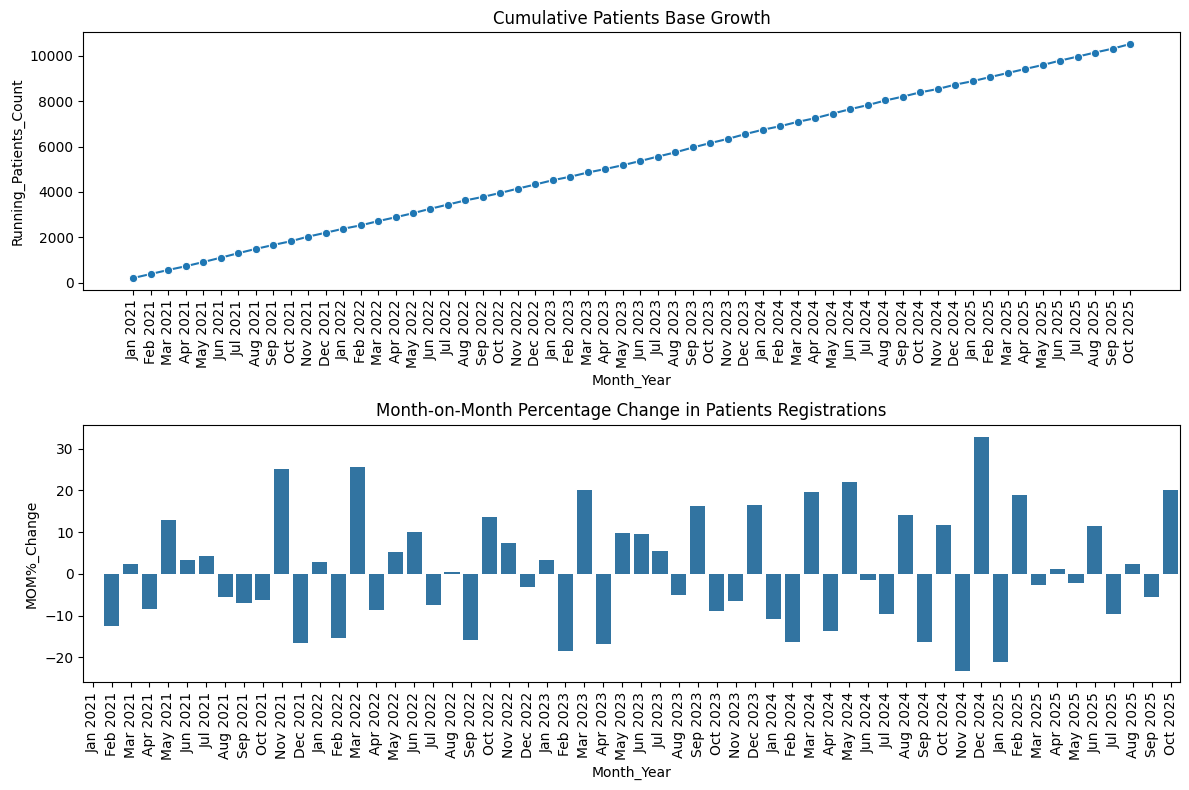

In [205]:
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
sns.lineplot(data=samp,x=samp.index,y=samp['Running_Patients_Count'],marker='o')
plt.title(f'Cumulative Patients Base Growth')
plt.xticks(rotation=90)

plt.subplot(2,1,2)
ax = sns.barplot(data=samp,x=samp.index,y=samp['MOM%_Change'])
plt.title(f'Month-on-Month Percentage Change in Patients Registrations')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

###### Inference - The cumulative chart shows a steady increase in overall patient base, while the MoM% Chart highlights monthly fluctuations, with some months showing positive growth and others showing a decline.


#### 2) Doctors Centric Analysis

##### KPIs

In [206]:
td = df2['doctor_id'].nunique()
ts = df2['specialization'].nunique()
avg_exp = df2['experience'].mean()
tb = df2['branch'].nunique()
sd_per = str((df2['experience'][df2['experience']>=10].shape[0] / td)*100) + '%'
avg_d_per_b = (df2['doctor_id'].nunique() / df2['branch'].nunique())

In [207]:
res = pd.DataFrame({'Metric':['Total Doctors','Total Specializations','Average Experience (in years)',
                             'Total Hospital Branches','Senior Doctors Percentage','Average Doctors per Branch'],
                   'Value':[td,ts,avg_exp,tb,sd_per,avg_d_per_b]})
res

,Metric,Value
0,Total Doctors,200
1,Total Specializations,8
2,Average Experience (in years),21.1
3,Total Hospital Branches,25
4,Senior Doctors Percentage,82.0%
5,Average Doctors per Branch,8.0


##### Insights

##### 1) Top 5 doctors by appointment volume

In [208]:
samp = pd.merge(df2,df4,on='doctor_id',how='inner')
samp['full_name'] = samp['fname'] + ' ' + samp['lname']
# samp.head()

In [209]:
res = samp.groupby(['doctor_id','full_name'])['ap_id'].count().reset_index()
res.sort_values('ap_id',ascending=False,inplace=True)
res['full_name'] = 'Dr ' + res['full_name']
res.columns = ['Doctor_id','Name','Appointments']
res = res.head(5)
res.index = list(range(len(res)))
res

,Doctor_id,Name,Appointments
0,D110,Dr Karishma Menon,126
1,D170,Dr Karan Ahmad,125
2,D141,Dr Nisha Chitale,121
3,D005,Dr Shruti Bose,116
4,D192,Dr Aisha Kaur Chauhan,113


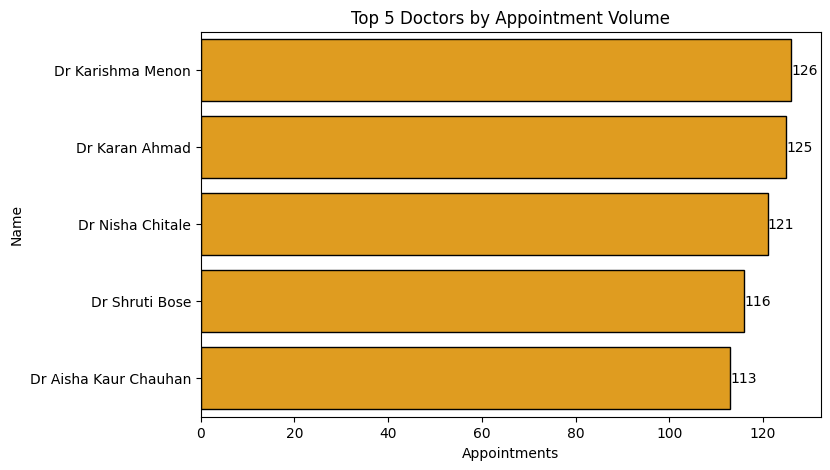

In [210]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=res,y='Name',x='Appointments',color='orange',edgecolor='black')
ax.bar_label(ax.containers[0])
plt.title(f'Top 5 Doctors by Appointment Volume')
plt.show()

###### Inference- With 126 appointments, Dr Karishma Menon is the most consulted doctor, while the remaining top doctors also handle over 110 appointments, reflecting a concentrated workload among top performers.

##### 2) Doctors Workload Distribution (High vs Low Load)

In [211]:
samp = pd.merge(df2,df4,on='doctor_id',how='inner')
res = samp.groupby('doctor_id')['ap_id'].count().reset_index()
res.columns = ['Doctor_ID','Appointments']
# res.head()

In [212]:
q1 = res['Appointments'].quantile(0.25)
q3 = res['Appointments'].quantile(0.75)
res[['Appointments']].describe().T

,count,mean,std,min,25%,50%,75%,max
Appointments,200.0,75.0,15.024603,39.0,67.0,73.0,82.0,126.0


In [213]:
# Creating column 'Workload_Category' in res dataframe.
res['Workload Category'] = res['Appointments'].apply(lambda x: 'High Load' if x>=q3 
                                                     else ('Low Load' if x<=q1 else 'Medium Load'))
res = res[res['Workload Category']!='Medium Load']
res.head()

,Doctor_ID,Appointments,Workload Category
1,D002,48,Low Load
4,D005,116,High Load
6,D007,52,Low Load
11,D012,90,High Load
12,D013,82,High Load


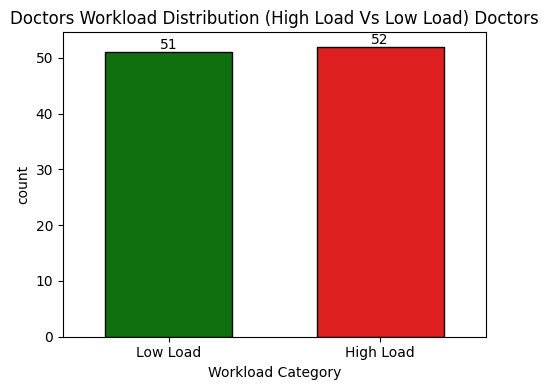

In [214]:
plt.figure(figsize=(5,4))
ax = sns.countplot(data=res,x='Workload Category',edgecolor='black',width=0.6,palette=['green','red'])
for i in ax.containers:
    ax.bar_label(i)
plt.title(f'Doctors Workload Distribution (High Load Vs Low Load) Doctors')
plt.tight_layout()
plt.show()

In [215]:
# Calculating Share for High load and Low load doctors.  
total_doctors = samp['doctor_id'].nunique()
HL_doctors = res['Workload Category'][res['Workload Category']=='High Load'].shape[0]
LL_doctors = res['Workload Category'][res['Workload Category']=='Low Load'].shape[0]
HL_doctors_Share = str((HL_doctors / total_doctors)*100) + '%'
LL_doctors_Share = str((LL_doctors / total_doctors)*100) + '%'
print('High_Load_Doctors_Share =',HL_doctors_Share)
print('Low_Load_Doctors_Share =',LL_doctors_Share)

High_Load_Doctors_Share = 26.0%
Low_Load_Doctors_Share = 25.5%


###### Inference - Out of the total doctors, 52 (26.0%) fall into the high-load category, while 51 (25.5%) are low-load, indicating a clear imbalance in workload distribution across doctors.

##### 3) Top 5 Most Demanded Specializations

In [216]:
samp = pd.merge(df2,df4,on='doctor_id',how='inner')
# samp.head()

In [217]:
res = samp.groupby('specialization')['ap_id'].count().reset_index()
res.columns = ['Specialization','Appointments']
res['Rank'] = res['Appointments'].rank(method='dense',ascending=False)
res.sort_values('Rank',inplace=True)
res = res[['Specialization','Appointments']][res['Rank']<6].set_index('Specialization')
res

,Appointments
Specialization,
Dermatologist,4500
Cardiologist,1885
Radiologist,1865
Family Doctor,1554
Oncologist,1522


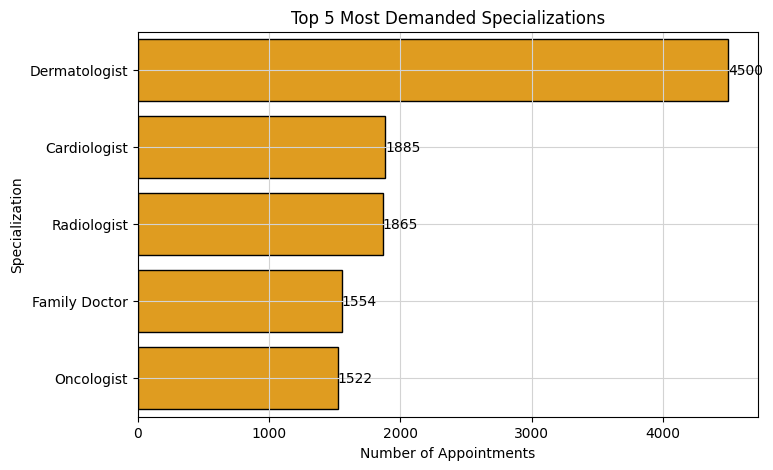

In [218]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=res,y='Specialization',x='Appointments',edgecolor='black',color='orange')
ax.bar_label(ax.containers[0])
plt.title(f'Top 5 Most Demanded Specializations')
plt.xlabel('Number of Appointments')
plt.grid(color='lightgrey')
plt.show()

###### Inference - Dermatologist leads specialization demand with (4500) appointments, more than double the volume of Cardiology (1885) and Radiology (1865), highlighting a strong concentration of patient visits in this department.

##### 4) Top 10 Doctors by Revenue Contribution

In [219]:
samp = pd.merge(df2,df4,on='doctor_id',how='inner')
samp = pd.merge(samp,df3,left_on='ap_id',right_on='appointment_id',how='inner')
samp['full_name'] = 'Dr ' + samp['fname'] +' '+ samp['lname']
# samp.head()

In [220]:
res = samp.groupby('full_name')['amount'].sum().reset_index()
res.columns = ['Doctor Name','Revenue']
res['Total Revenue'] = res['Revenue'].sum()
res['Revenue Contribution (%)'] = round((res['Revenue'] / res['Total Revenue']) *100,2)
res.sort_values('Revenue',ascending=False,inplace=True)
res = res.head(10)
# res

table_res = res.copy()
table_res['Revenue Contribution (%)'] = table_res['Revenue Contribution (%)'].astype(str) + '%' 
table_res.index = list(range(len(table_res)))
table_res = table_res[['Doctor Name','Revenue','Revenue Contribution (%)']]
table_res

,Doctor Name,Revenue,Revenue Contribution (%)
0,Dr Latika Basak,6116781.0,3.55%
1,Dr Monika Kaur,5306456.0,3.08%
2,Dr Aadhya Shukla,5182683.0,3.0%
3,Dr Krupa Anand,5176050.0,3.0%
4,Dr Hrithik Roy,4959298.0,2.87%
5,Dr Tarun Gupta,4955143.0,2.87%
6,Dr Vishal Bajaj,4952810.0,2.87%
7,Dr Aarohi Pawar,4881925.0,2.83%
8,Dr Rishabh Anand,4792601.0,2.78%
9,Dr Aditi Priya Roy,4781134.0,2.77%


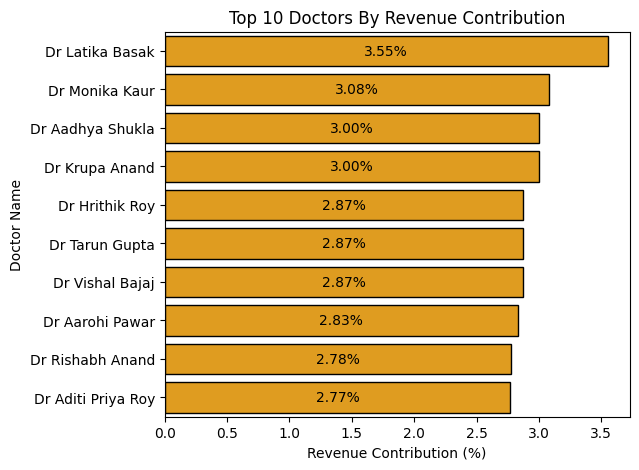

In [221]:
plt.figure(figsize=(6,5))
ax = sns.barplot(y=res['Doctor Name'],x=res['Revenue Contribution (%)'],edgecolor='black',color='orange')
ax.bar_label(ax.containers[0],fmt='%.2f%%',label_type='center')
plt.title(f'Top 10 Doctors By Revenue Contribution')
plt.show()

###### Inference - The top 10 doctors individually contribute between (2.77%) and (3.55%) of the total revenue, indicating that overall revenue is distributed across multiple high-performing doctors rather than being dominated by a single individual.

##### 5) Top 3 Revenue-Generating Doctors Within Each Specialization

In [222]:
samp = pd.merge(df2,df4,on='doctor_id',how='inner')
samp = pd.merge(samp,df3,left_on='ap_id',right_on='appointment_id',how='inner')
samp['full_name'] = 'Dr ' + samp['fname'] + ' '+ samp['lname']
# samp.columns

In [223]:
res = samp.groupby(['specialization','full_name'])['amount'].sum().reset_index()
res.columns = ['Specialization','Doctor Name','Revenue']
res['Top Rank'] = res.groupby('Specialization')['Revenue'].rank(method='dense',ascending=False)
res = res[res['Top Rank']<=3]
res.sort_values(['Specialization','Top Rank'],inplace=True)
res.index = list(range(len(res)))
res

,Specialization,Doctor Name,Revenue,Top Rank
0,Cardiologist,Dr Pari Iyer,91765.0,1.0
1,Cardiologist,Dr Diya Verma,85353.0,2.0
2,Cardiologist,Dr Ritu Farooq,82732.0,3.0
3,Dermatologist,Dr Megha Pawar,115664.0,1.0
4,Dermatologist,Dr Deepa Dubey,110704.0,2.0
5,Dermatologist,Dr Aradhya Grover,96435.0,3.0
6,Family Doctor,Dr Shruti Bose,107269.0,1.0
7,Family Doctor,Dr Karishma Menon,103688.0,2.0
8,Family Doctor,Dr Aisha Kaur Chauhan,96953.0,3.0
9,General Physician,Dr Lavanya Gaikwad,65011.0,1.0


###### Inference - Among all specializaions, Surgeons shows the highest revenue concentration, with their top 3 doctors generating the highest revenues compared to other departments. 

#### 3) Billing Centric Analysis

##### KPIs

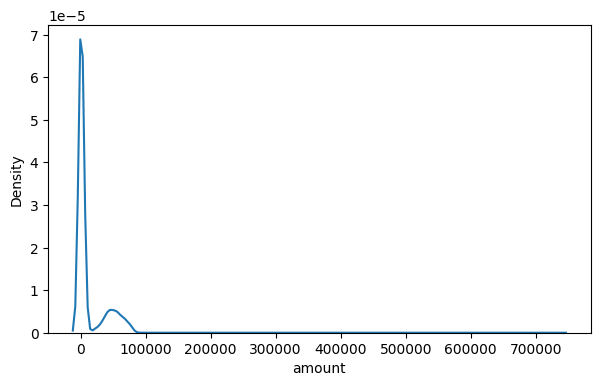

In [224]:
plt.figure(figsize=(7,4))
sns.kdeplot(data=df3,x='amount')
plt.show()

In [225]:
tr = df3['amount'].sum()
tb = df3['bill_id'].nunique()
avg_ba = df3['amount'].mean()
med_ba = df3['amount'].median() # Calculating median bill amount because amount column is right skewed 
max_b = df3['amount'].max()
min_b = df3['amount'].min()

res = pd.DataFrame({'Metric':['Total Revenue','Total Bills','Average Bill Amount','Median Bill Amount',
                              'Maximum Bill Amount','Minimum Bill Amount'],
                    'Value':[tr,tb,avg_ba,med_ba,max_b,min_b]})
res['Value'] = res['Value'].apply(lambda x: f'{x:,.2f}')
res

,Metric,Value
0,Total Revenue,"172,535,732.00"
1,Total Bills,"13,851.00"
2,Average Bill Amount,"12,456.55"
3,Median Bill Amount,"1,093.00"
4,Maximum Bill Amount,"734,310.00"
5,Minimum Bill Amount,300.00


##### Insights

##### 1) Monthly Revenue Trend & MoM% Growth

In [226]:
# Creating Year, Month and Monthname columns in Billing table.
df3['bill_year'] = df3['bill_date'].dt.year
df3['bill_month'] = df3['bill_date'].dt.month
df3['bill_month_name'] = df3['bill_date'].dt.month_name()
# df3.columns

In [227]:
samp = df3.copy()
samp['month_year'] = samp['bill_date'].dt.to_period('M').dt.strftime('%b %Y')

In [228]:
res = samp.groupby(['bill_year','bill_month','month_year'])['amount'].sum().reset_index()
res.sort_values(['bill_year','bill_month'],inplace=True)
res = res[['month_year','amount']]
res.columns = ['Month_Year','Current_Month_Revenue']
res['Previous_Month_Revenue'] = res['Current_Month_Revenue'].shift(1).fillna(0)
res['MoM%_Change'] = round((((res['Current_Month_Revenue'] - res['Previous_Month_Revenue']) /
                      res['Previous_Month_Revenue'])*100).replace({np.inf:0}),2).astype(str) + '%'
res

,Month_Year,Current_Month_Revenue,Previous_Month_Revenue,MoM%_Change
0,Jan 2023,3468574.0,0.0,0.0%
1,Feb 2023,5063290.0,3468574.0,45.98%
2,Mar 2023,6068246.0,5063290.0,19.85%
3,Apr 2023,4761005.0,6068246.0,-21.54%
4,May 2023,5609674.0,4761005.0,17.83%
5,Jun 2023,5168858.0,5609674.0,-7.86%
6,Jul 2023,4991028.0,5168858.0,-3.44%
7,Aug 2023,4692417.0,4991028.0,-5.98%
8,Sep 2023,5410350.0,4692417.0,15.3%
9,Oct 2023,5053832.0,5410350.0,-6.59%


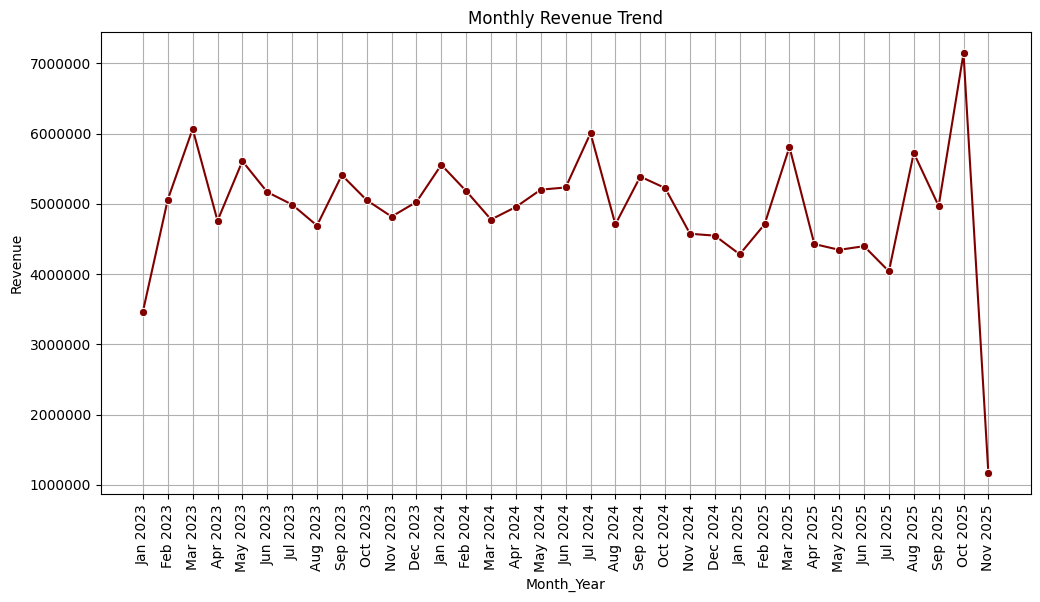

In [229]:
plt.figure(figsize=(12,6))
sns.lineplot(data=res,x='Month_Year',y='Current_Month_Revenue',marker='o',color='maroon')
plt.title(f'Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain',axis='y')
plt.grid()
plt.show()

In [230]:
# Checking records for November 2025.
print(df3[(df3['bill_year']==2025) & (df3['bill_month']==11)].shape[0])

75


###### Inference - Revenue trends shows consistency across months, while the dip in November 2025 reflects incomplete billing data rather than actual performance.

##### 2) Insurance vs Self-Pay Revenue Mix

In [231]:
df3['payment_method'].unique()

array(['UPI', 'Cash', 'Insurance', 'Credit Card'], dtype=object)

In [232]:
total_revenue = df3['amount'].sum()
rev_by_ins = df3['amount'][df3['payment_method']=='Insurance'].sum()
rev_by_ins_per = round((rev_by_ins / total_revenue)*100,2).astype(str) + '%'
selfpay_rev = df3['amount'][df3['payment_method']!='Insurance'].sum()
selfpay_rev_per = round((selfpay_rev / total_revenue)*100,2).astype(str) + '%'

res = pd.DataFrame({'Payment Type':['Insurance','Self-Pay'],
                   'Revenue':[rev_by_ins,selfpay_rev],
                   'Revenue (%)':[rev_by_ins_per,selfpay_rev_per]})
res                   

,Payment Type,Revenue,Revenue (%)
0,Insurance,28264560.0,16.38%
1,Self-Pay,144271172.0,83.62%


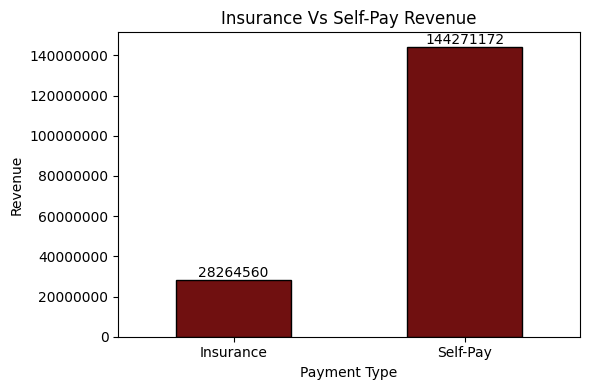

In [233]:
plt.figure(figsize=(6,4))
ax = sns.barplot(data=res,x='Payment Type',y='Revenue',edgecolor='black',color='maroon',width=0.5)
ax.bar_label(ax.containers[0],fmt='%.0f')
plt.title(f'Insurance Vs Self-Pay Revenue')
plt.ticklabel_format(axis='y',style='plain')
plt.tight_layout()
plt.show()

###### Inference - Self-Pay contributes approximately ₹114.3 million (83.62%) of total revenue, while insurance accounts for only ₹28.3 million (16.38%) indicating a strong reliance on out-of-pocket payments.

##### 3) Pending Payments & Outstanding Revenue Trend

In [234]:
df3['payment_status'].unique()

array(['Pending', 'Paid', 'Failed'], dtype=object)

In [235]:
samp = df3.copy()
samp['month_year'] = samp['bill_date'].dt.to_period('M').dt.strftime('%b %Y')

res = samp.groupby(['bill_year','bill_month','month_year','payment_status'])['amount'].sum().reset_index()

total_billed = res.groupby(['bill_year','bill_month','month_year'])['amount'].sum().reset_index()
total_billed.sort_values(['bill_year','bill_month'],inplace=True)
total_billed

ots_billed = res[res['payment_status']!='Paid'].groupby(['bill_year','bill_month','month_year'])['amount'].sum().reset_index()
ots_billed.sort_values(['bill_year','bill_month'],inplace=True)
ots_billed

final_res = pd.merge(total_billed,ots_billed,on=['bill_year','bill_month','month_year'],how='left')
final_res = final_res[['month_year','amount_x','amount_y']]
final_res.columns = ['Month_Year','Total Revenue','Outstanding Revenue']
final_res['Outstanding Revenue (%)'] = round((final_res['Outstanding Revenue'] / 
                                             final_res['Total Revenue'])*100,2).astype(str) + '%'
final_res.set_index('Month_Year',inplace=True)
final_res

,Total Revenue,Outstanding Revenue,Outstanding Revenue (%)
Month_Year,,,
Jan 2023,3468574.0,730307.0,21.05%
Feb 2023,5063290.0,1032753.0,20.4%
Mar 2023,6068246.0,1156150.0,19.05%
Apr 2023,4761005.0,927745.0,19.49%
May 2023,5609674.0,1455422.0,25.94%
Jun 2023,5168858.0,1358419.0,26.28%
Jul 2023,4991028.0,1187221.0,23.79%
Aug 2023,4692417.0,602641.0,12.84%
Sep 2023,5410350.0,1107425.0,20.47%


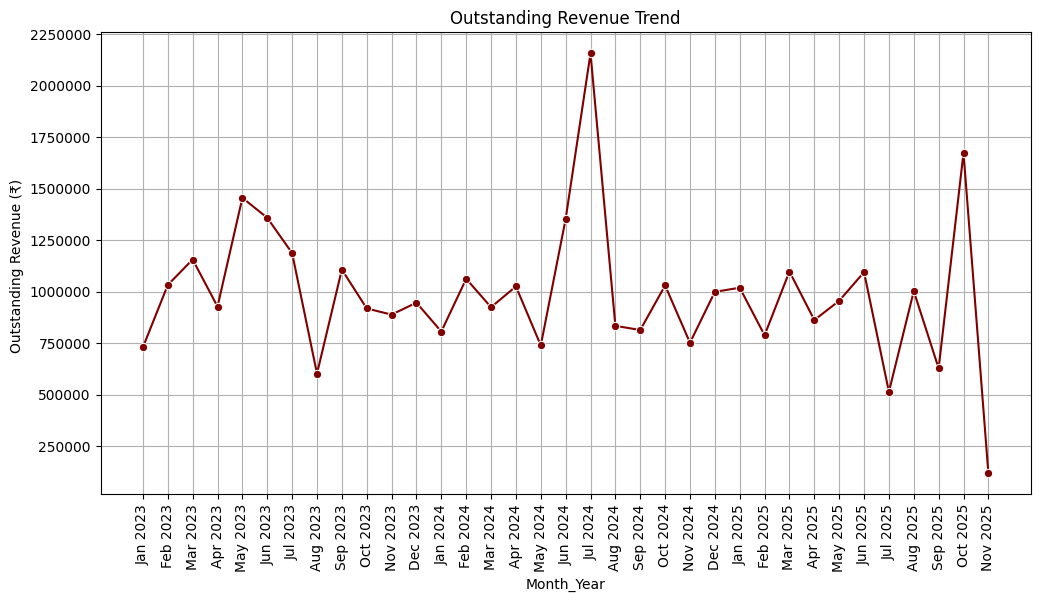

In [236]:
plt.figure(figsize=(12,6))
sns.lineplot(data=final_res,x=final_res.index,y='Outstanding Revenue',marker='o',color='maroon')
plt.title(f'Outstanding Revenue Trend')
plt.xticks(rotation=90)
plt.ticklabel_format(axis='y',style='plain')
plt.ylabel(f'Outstanding Revenue (₹) ')
plt.grid()
plt.show()

###### Inference - Outstanding revenue fluctuates month to month, with occasional spikes indicating delayed collection, while the sharp drop in the final month reflects partial billing data availability

##### 4) Revenue Leakage: Appointments vs Billing

In [237]:
print('Billing Table unique reasons for visit :',df3['reason_for_visit'].unique())
print('Appointment Table unique reasons for visit :',df4['reason_for_visit'].unique())

Billing Table unique reasons for visit : ['Consultation' 'Routine Check-Up' 'Diagnosis' 'Treatment']
Appointment Table unique reasons for visit : ['Consultation' 'Routine Check-Up' 'Diagnosis' 'Follow-up' 'Treatment']


In [238]:
samp_df4 = df4[df4['reason_for_visit']!='Follow-up']
# Excluding rows from appointments table where reason_for_visit is 'Follow-up', as there are no bills for 'Follow-up'. 

merge = pd.merge(samp_df4,df3,left_on='ap_id',right_on='appointment_id',how='left')

total_app = df4['ap_id'].nunique()
fol_up_app = df4['ap_id'][df4['reason_for_visit']=='Follow-up'].nunique()
billable_app = total_app - fol_up_app
app_with_bill = merge['ap_id'][~merge['bill_id'].isnull()].nunique()
app_without_bill = billable_app - app_with_bill
rev_leak_per = str(round((app_without_bill / billable_app)*100,2)) + '%'

res = pd.DataFrame({'Metric':['Total Appointments','Follow-up Appointments','Billable Appointments',
                             'Appointments with Billing','Unbilled Billable Appointments','Revenue Leakage (%)'],
                   'Value':[total_app,fol_up_app,billable_app,app_with_bill,app_without_bill,rev_leak_per]})
res

,Metric,Value
0,Total Appointments,15000
1,Follow-up Appointments,748
2,Billable Appointments,14252
3,Appointments with Billing,13837
4,Unbilled Billable Appointments,415
5,Revenue Leakage (%),2.91%


###### Inference - Out of 14,256 billable appointments, 13,841 (97.1%) were successfully billed, while 415 appointments (2.9%) did not generate billing, indicating low but non-negligible potential revenue leakage after excluding non-billable follow-up visits.

##### 5) Billing Frequency Distribution per Patient

In [239]:
total_pat_billed = df3['patient_id'].nunique()

samp = df3.groupby('patient_id')['bill_id'].count().reset_index()

one_b = samp['patient_id'][samp['bill_id']==1].nunique()
one_b_per = str(round((one_b / total_pat_billed)*100,2)) + '%'

two_b = samp['patient_id'][samp['bill_id']==2].nunique()
two_b_per = str(round((two_b / total_pat_billed)*100,2)) + '%'

high_f_b = samp['patient_id'][samp['bill_id']>2].nunique()
high_f_b_per = str(round((high_f_b / total_pat_billed)*100,2)) + '%'

res = pd.DataFrame({'Billing Frequency Segment':['Single-Time Billing','Two-Time Billing','High-Frequency Billing'],
                   'Patient Count':[one_b,two_b,high_f_b],
                   '% of Patients':[one_b_per,two_b_per,high_f_b_per]})
res

,Billing Frequency Segment,Patient Count,% of Patients
0,Single-Time Billing,7232,71.46%
1,Two-Time Billing,2045,20.21%
2,High-Frequency Billing,843,8.33%


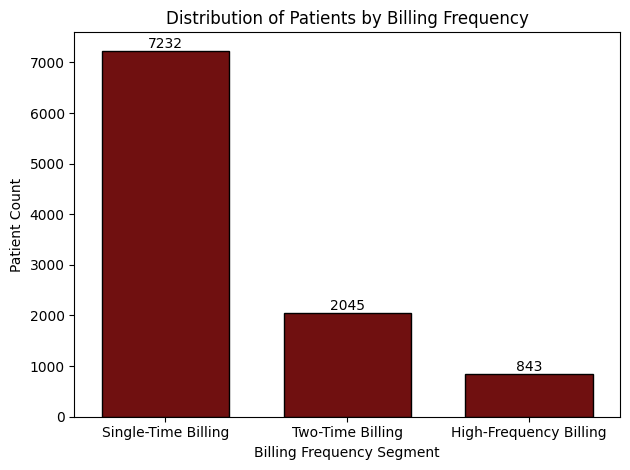

In [240]:
ax = sns.barplot(data=res,x='Billing Frequency Segment',y='Patient Count',edgecolor='black',color='maroon',width=0.7)
ax.bar_label(ax.containers[0])
plt.title(f'Distribution of Patients by Billing Frequency')
plt.tight_layout()
plt.show()

###### Inference - 7,232 patients are billed only once, compared to 2,045 with two bills and 843 with 3 or more bills, suggesting revenue is primarily driven by one-time billed patients.

#### 4) Appointment Centric Analysis

##### KPIs

In [241]:
df4['status'].unique()

array(['Cancelled', 'Completed', 'Scheduled', 'No-Show'], dtype=object)

In [242]:
total_app = df4['ap_id'].nunique()
total_p = df4['patient_id'].nunique()
avg_app_per_p = round((total_app / total_p),2)
unique_app_dates = df4['ap_date'].nunique()
avg_app_per_day = round((total_app / unique_app_dates),2)
completed_app = df4[df4['status']=='Completed'].shape[0]
completed_app_rate = str(round((completed_app / total_app)*100,2)) + '%'
cancelled_app = df4[df4['status']=='Cancelled'].shape[0]
cancelled_app_rate = str(round((cancelled_app / total_app)*100,2)) + '%'
no_show_app = df4[df4['status']=='No-Show'].shape[0]
no_show_app_rate = str(round((no_show_app / total_app)*100,2)) + '%'

res = pd.DataFrame({'Metric':['Total Appointments','Average Appointments per Patient','Average Appointments per Day',
                             'Completed Appointments Rate','Cancelled Appointments Rate','No-Show Appointments Rate'],
                   'Value':[total_app,avg_app_per_p,avg_app_per_day,completed_app_rate,cancelled_app_rate,no_show_app_rate]})
res

,Metric,Value
0,Total Appointments,15000
1,Average Appointments per Patient,1.4
2,Average Appointments per Day,14.49
3,Completed Appointments Rate,70.84%
4,Cancelled Appointments Rate,10.0%
5,No-Show Appointments Rate,4.53%


##### Insights

##### 1) Monthly Appointments Trend

In [243]:
# Creating Year, Month, Month_Name and Month_Year columns in Appointment Table.
df4['ap_year'] = df4['ap_date'].dt.year
df4['ap_month'] = df4['ap_date'].dt.month
df4['ap_month_name'] = df4['ap_date'].dt.month_name()
df4['month_year'] = df4['ap_date'].dt.strftime('%b %Y')
# df4.head()

In [244]:
res = df4.groupby(['ap_year','ap_month','month_year'])['ap_id'].nunique().reset_index()
res.sort_values(['ap_year','ap_month'],ascending=[True,True],inplace=True)
res = res[['month_year','ap_id']]
res.columns = ['Month_Year','Appointments']
res.set_index('Month_Year',inplace=True)
res

,Appointments
Month_Year,
Jan 2023,423
Feb 2023,420
Mar 2023,448
Apr 2023,455
May 2023,466
Jun 2023,421
Jul 2023,434
Aug 2023,491
Sep 2023,419


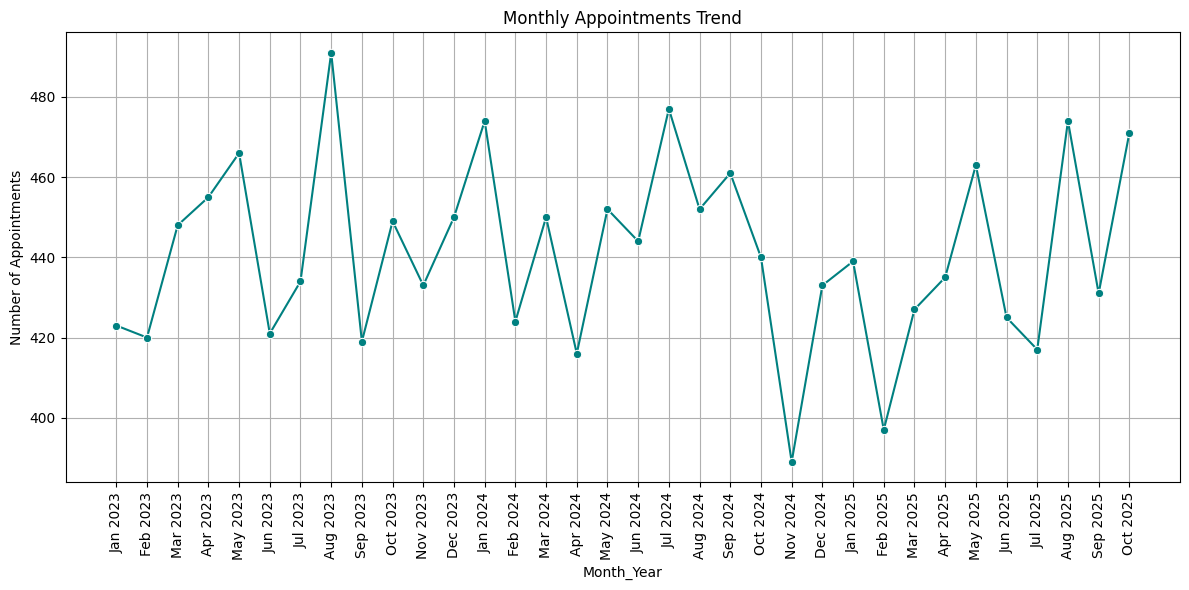

In [245]:
plt.figure(figsize=(12,6))
sns.lineplot(data=res,x=res.index,y='Appointments',color='teal',marker='o')
plt.title(f'Monthly Appointments Trend')
plt.xticks(rotation=90)
plt.ylabel(f'Number of Appointments')
plt.grid()
plt.tight_layout()
plt.show()

###### Inference - Monthly appointments remain relatively stable with moderate fluctuations, indicating consistent patient demand with occasional seasonal spikes and dips.

##### 2) Month-over-Month % Change in Appointments

In [246]:
df4.columns

Index(['ap_id', 'patient_id', 'doctor_id', 'ap_time', 'reason_for_visit',
       'status', 'ap_date', 'ap_year', 'ap_month', 'ap_month_name',
       'month_year'],
      dtype='object')

In [247]:
res = df4.groupby(['ap_year','ap_month','month_year'])['ap_id'].nunique().reset_index()
res.sort_values(['ap_year','ap_month'],ascending=[True,True],inplace=True)
res = res[['month_year','ap_id']]
res.columns = ['Month_Year','Current Month Appointments']
res['Previous Month Appointments'] = res['Current Month Appointments'].shift(1).fillna(0).astype(int)
res['MoM%_Change'] = (((res['Current Month Appointments'] - res['Previous Month Appointments']) / 
                      res['Previous Month Appointments'])*100).round(2).replace(np.inf,0)

table_res = res.copy()
table_res['MoM%_Change'] = table_res['MoM%_Change'].astype(str) + '%'
table_res.set_index('Month_Year',inplace=True)
table_res

,Current Month Appointments,Previous Month Appointments,MoM%_Change
Month_Year,,,
Jan 2023,423,0,0.0%
Feb 2023,420,423,-0.71%
Mar 2023,448,420,6.67%
Apr 2023,455,448,1.56%
May 2023,466,455,2.42%
Jun 2023,421,466,-9.66%
Jul 2023,434,421,3.09%
Aug 2023,491,434,13.13%
Sep 2023,419,491,-14.66%


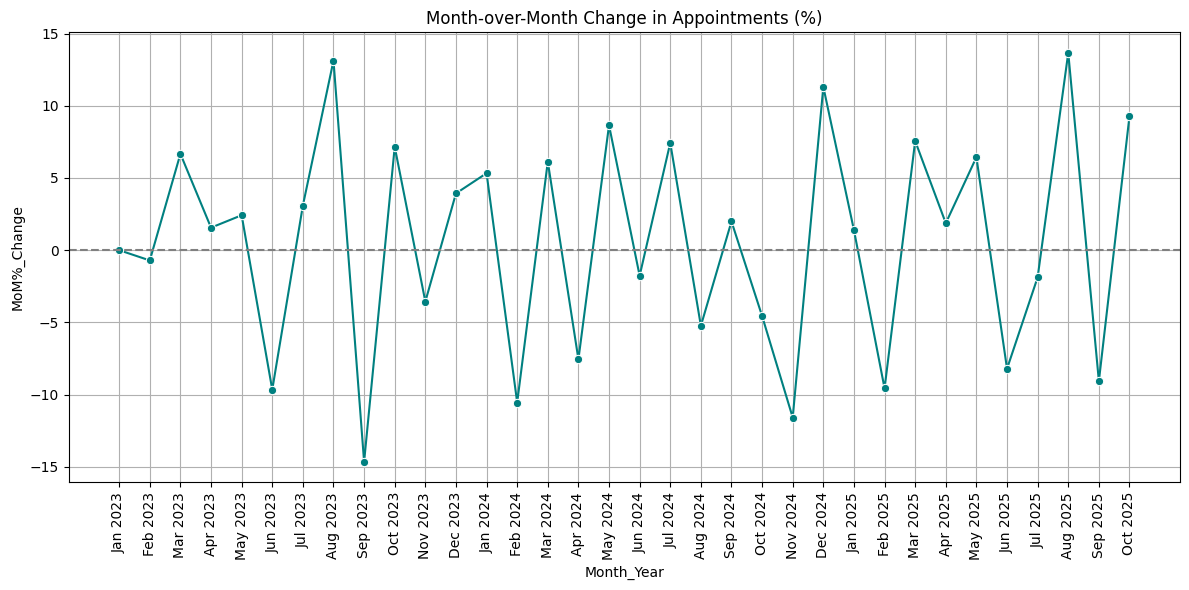

In [248]:
plt.figure(figsize=(12,6))
sns.lineplot(data=res,x='Month_Year',y='MoM%_Change',color='teal',marker='o')
plt.axhline(0,linestyle='--',color='gray')
plt.title(f'Month-over-Month Change in Appointments (%)')
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()
plt.show()

###### Inference - Month-over-Month appointment growth fluctuates between increases and declines, indicating short-term demand volatility without a consistent growth trend.

##### 3) Appointment Volume by Day of the Week


In [249]:
# Creating Day_Name column in the Appointments table.
df4['day_name'] = df4['ap_date'].dt.day_name()
# df4.head()

In [250]:
res = df4.groupby('day_name')['ap_id'].nunique().reset_index()
res.columns = ['Day Name','Appointments']
res.set_index('Day Name',inplace=True)
total_appointments = df4['ap_id'].nunique()
res['% of Total'] = round((res['Appointments'] / total_appointments)*100,2).astype(str) + '%'
res.sort_values('Appointments',ascending=False,inplace=True)
res

,Appointments,% of Total
Day Name,,
Thursday,2183,14.55%
Wednesday,2181,14.54%
Tuesday,2161,14.41%
Friday,2145,14.3%
Monday,2111,14.07%
Saturday,2110,14.07%
Sunday,2109,14.06%


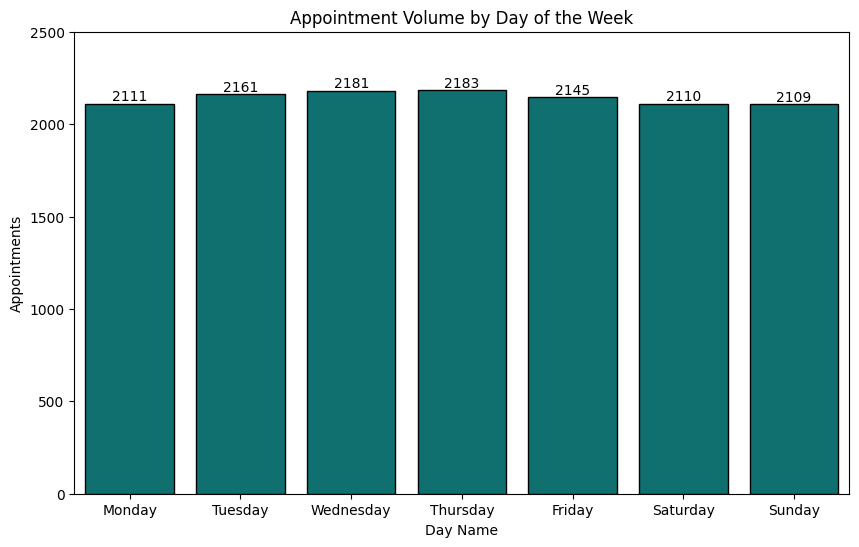

In [251]:
plt.figure(figsize=(10,6))
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ax = sns.barplot(data=res,x='Day Name',y='Appointments',edgecolor='black',color='teal',order=order)
ax.bar_label(ax.containers[0])
plt.title(f'Appointment Volume by Day of the Week')
plt.yticks(list(range(0,3000,500)))
plt.show()

###### Inference - Appointment volumes are fairly evenly distributed across the week, with marginally higher demand on the mid-week days, indicating consistent operational load.

##### 4) Peak Appointments Hour Pattern

In [252]:
# Creating Hour column in Appointments table. 
df4['hour'] = df4['ap_time'].dt.hour

In [253]:
res = df4.groupby('hour')['ap_id'].nunique().reset_index()
res.columns = ['Hour','Appointments']
res.sort_values('Hour',ascending=True,inplace=True)
res['Hour_Label'] = pd.to_datetime(res['Hour'], format='%H').dt.strftime('%I %p')
table_res = res[['Hour_Label','Appointments']]
table_res

,Hour_Label,Appointments
0,08 AM,1245
1,09 AM,1213
2,10 AM,1263
3,11 AM,1225
4,12 PM,1248
5,01 PM,1294
6,02 PM,1256
7,03 PM,1206
8,04 PM,1245
9,05 PM,1253


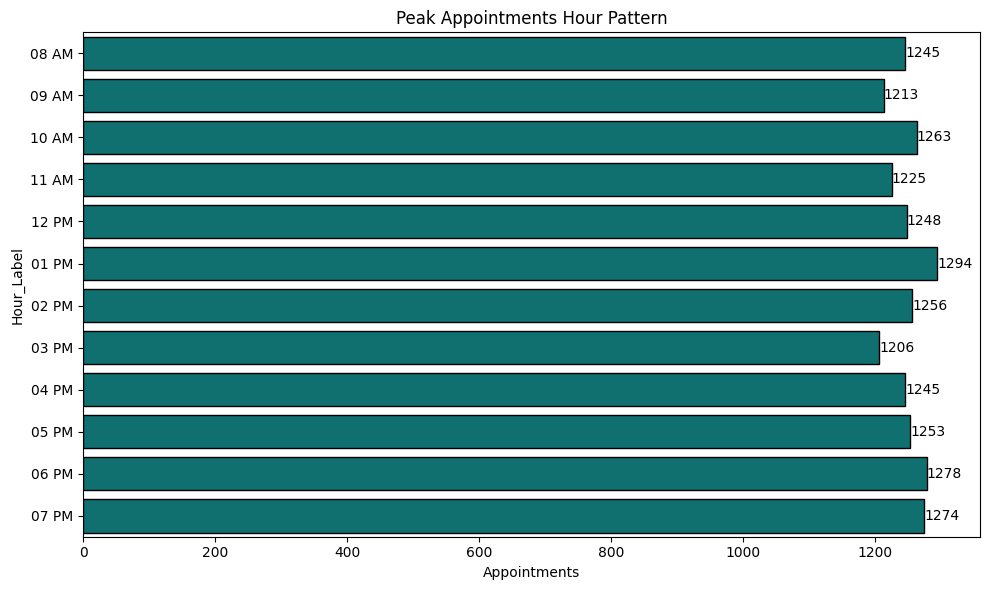

In [254]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=table_res,y='Hour_Label',x='Appointments',color='teal',edgecolor='black')
ax.bar_label(ax.containers[0])
plt.title(f'Peak Appointments Hour Pattern')
plt.tight_layout()
plt.show()

###### Inference - Appointment volumes remain relatively consistent across operating hours, with slightly higher activity observed from late morning to early evening.

##### 5) Cancellation & No-Show Trend Over Time

In [255]:
cancel_app = df4[df4['status']=='Cancelled'].groupby(['ap_year','ap_month','month_year'])['ap_id'].nunique().reset_index()
cancel_app.sort_values(['ap_year','ap_month'],ascending=True,inplace=True)

no_show_app = df4[df4['status']=='No-Show'].groupby(['ap_year','ap_month','month_year'])['ap_id'].nunique().reset_index()
no_show_app.sort_values(['ap_year','ap_month'],ascending=True,inplace=True)

res = pd.merge(cancel_app,no_show_app,on=['ap_year','ap_month','month_year'],how='inner')
res = res[['month_year','ap_id_x','ap_id_y']]
res.columns = ['Month_Year','Cancelled Appointments','No-Show Appointments']
res.set_index('Month_Year',inplace=True)
res

,Cancelled Appointments,No-Show Appointments
Month_Year,,
Jan 2023,37,19
Feb 2023,50,19
Mar 2023,51,32
Apr 2023,41,21
May 2023,43,24
Jun 2023,45,15
Jul 2023,37,11
Aug 2023,49,25
Sep 2023,49,19


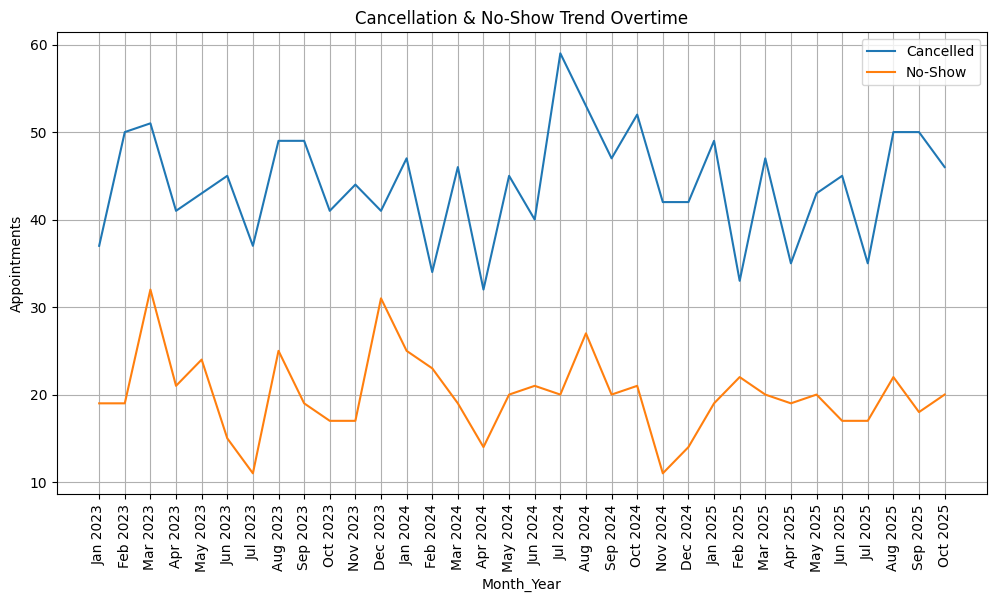

In [256]:
plt.figure(figsize=(12,6))
sns.lineplot(data=res,x=res.index,y='Cancelled Appointments',label='Cancelled')
sns.lineplot(data=res,x=res.index,y='No-Show Appointments',label='No-Show')
plt.title(f'Cancellation & No-Show Trend Overtime')
plt.xticks(rotation=90)
plt.legend()
plt.ylabel(f'Appointments')
plt.grid()
plt.show()

###### Inference - Both cancellations and no-shows show month-to-month variation, with cancellations consistently higher than no-shows, indicating a recurring loss of appointment slots.

#### 5) Treatment Centric Analysis

##### KPIs

In [257]:
total_rev = df5['cost'].sum()
total_tr = df5['treatment_id'].nunique()
avg_rev = round((total_rev / total_tr),2)
unique_tr_days = df5['treatment_date'].nunique()
avg_tr_per_day = round((total_tr / unique_tr_days),2)
median_tr_cost = df5['cost'].median() # Using median because 'cost' column in treatment table is right-skewed 
unique_tr_types = df5['treatment_type'].nunique()

res = pd.DataFrame({'Metric':['Total Treatment Revenue','Total Treatments Delivered',
                              'Average Revenue per Treatment','Average Treatments per Day','Median Treatment Cost',
                             'Unique Treatment Types Offered'],
                   'Value':[total_rev,total_tr,avg_rev,avg_tr_per_day,median_tr_cost,unique_tr_types]})
res['Value'] = res['Value'].apply(lambda x: f'{x:,.2f}') 
res

,Metric,Value
0,Total Treatment Revenue,"162,719,544.50"
1,Total Treatments Delivered,"6,750.00"
2,Average Revenue per Treatment,"24,106.60"
3,Average Treatments per Day,6.49
4,Median Treatment Cost,"5,333.00"
5,Unique Treatment Types Offered,9.00


##### Insights

##### 1) Treatment wise Revenue vs Volume Analysis

In [258]:
res = df5.groupby('treatment_type').agg({'cost':'sum','treatment_id':'nunique'}).reset_index()
res.columns = ['Treatment Type','Total Revenue','Total Treatments']
res.set_index('Treatment Type',inplace=True)
res.sort_values(['Total Revenue','Total Treatments'],ascending=False,inplace=True)
res

,Total Revenue,Total Treatments
Treatment Type,,
Hernia Repair,42674180.0,714
Radiation Therapy,40874362.0,752
Appendectomy,40054403.0,764
Chemotherapy,31214112.0,770
MRI Scan,3266525.0,652
CT Scan,2520084.0,598
Stress Test,1297623.0,934
ECG,483098.5,951
X-Ray,335157.0,615


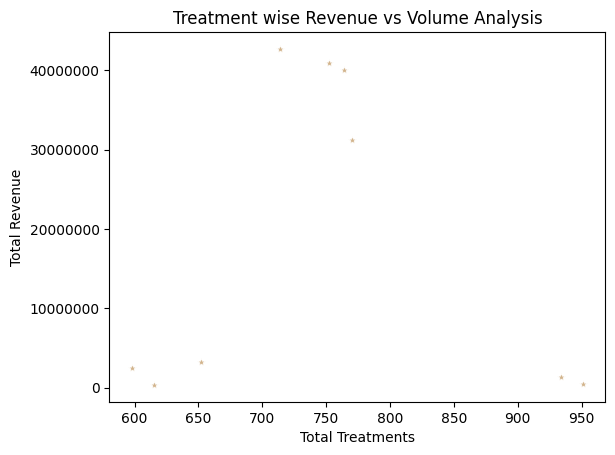

In [259]:
sns.scatterplot(data=res,x='Total Treatments',y='Total Revenue',color='tan',marker='*')
plt.title(f'Treatment wise Revenue vs Volume Analysis')
plt.ticklabel_format(style='plain',axis='y')
plt.show()

###### Inference - Some treatments are done very often but earn less revenue, while a few treatments earn more even if they are done fewer times. 

##### 2) Monthly Treatment Demand Trend with MoM Variations

In [260]:
# Creating Year, Month, Month_Name and Month_Year columns in Treatment table.
df5['year'] = df5['treatment_date'].dt.year
df5['month'] = df5['treatment_date'].dt.month
df5['month_name'] = df5['treatment_date'].dt.month_name()
# df5['month_year'] = df5['treatment_date'].dt.to_period('M').dt.strftime('%b %Y')
df5['month_year'] = df5['treatment_date'].dt.strftime('%b %Y')
# df5.head()

In [261]:
res = df5.groupby(['year','month','month_year'])['treatment_id'].nunique().reset_index()
res.sort_values(['year','month'],ascending=[True,True],inplace=True)
res = res[['month_year','treatment_id']]
res.columns = ['Month Year','Treatments']

table_res = res.copy()
table_res.columns = ['Month Year','Curr Month Treatments']
table_res['Prev Month Treatments'] = table_res['Curr Month Treatments'].shift(1).fillna(0).astype(int)
table_res['MoM%_Change'] = (((table_res['Curr Month Treatments'] - table_res['Prev Month Treatments']) / 
                            table_res['Prev Month Treatments'])*100).round(2).replace(np.inf,0).astype(str) + '%'
table_res.set_index('Month Year',inplace=True)
table_res

,Curr Month Treatments,Prev Month Treatments,MoM%_Change
Month Year,,,
Jan 2023,162,0,0.0%
Feb 2023,184,162,13.58%
Mar 2023,219,184,19.02%
Apr 2023,182,219,-16.89%
May 2023,224,182,23.08%
Jun 2023,206,224,-8.04%
Jul 2023,210,206,1.94%
Aug 2023,213,210,1.43%
Sep 2023,204,213,-4.23%


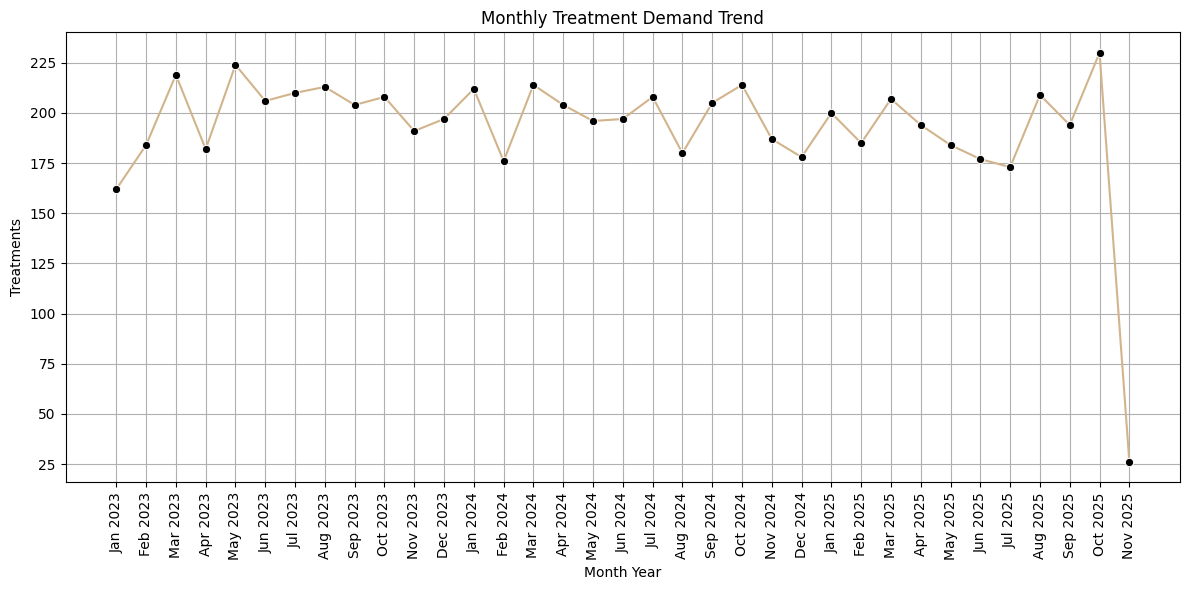

In [262]:
plt.figure(figsize=(12,6))
sns.lineplot(data=res,x='Month Year',y='Treatments',color='tan',marker='o',markerfacecolor='black')
plt.title(f'Monthly Treatment Demand Trend')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid()
plt.show()

###### Inference - Treatment demand is largely stable month-over-month with small variations, while the sudden drop in the last month likely reflects partial data.

##### 3) Treatment Utilization by Doctor Specialization

In [263]:
samp = pd.merge(df5,df4,left_on='appointment_id',right_on='ap_id',how='inner')
samp = pd.merge(samp,df2,on='doctor_id',how='inner')
# samp.head()

In [264]:
res = samp.groupby('specialization')['treatment_id'].nunique().reset_index()
res.columns = ['Specialization','Treatments']
res.sort_values('Treatments',ascending=False,inplace=True)
res.set_index('Specialization',inplace=True)
res

,Treatments
Specialization,
Cardiologist,1885
Radiologist,1865
Oncologist,1522
Surgeon,1478


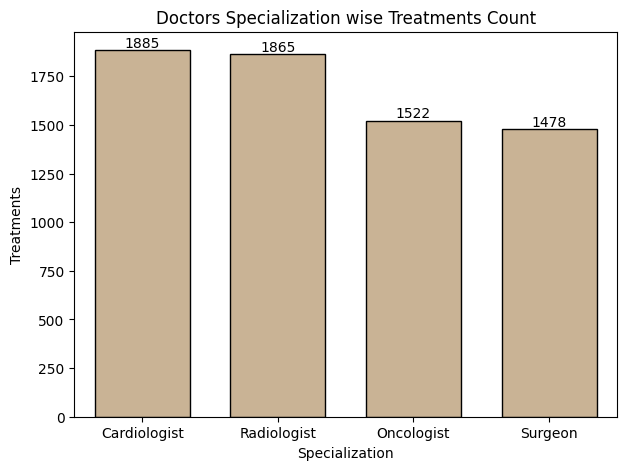

In [265]:
plt.figure(figsize=(7,5))
ax = sns.barplot(data=res,x=res.index,y='Treatments',color='tan',edgecolor='black',width=0.7)
ax.bar_label(ax.containers[0])
plt.title(f'Doctors Specialization wise Treatments Count')
plt.show()

###### Inference - Treatment delivery is concentrated among a few doctors specializations, with Cardiologists and Radiologists accounting for the highest treatment volumes. This indicates higher service demand and resource utilization in these specialties compared to others.

##### 4) Treatment Cost Variability & Pricing Consistency Analysis

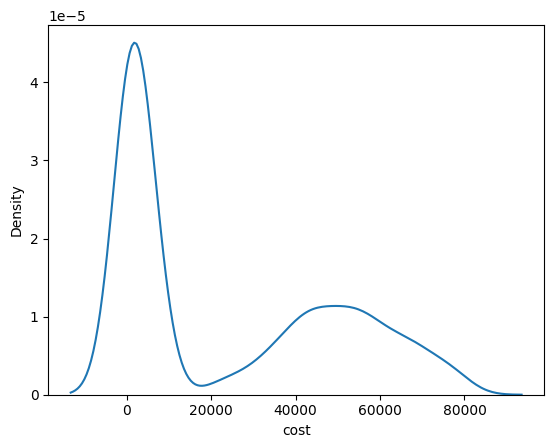

In [266]:
sns.kdeplot(df5['cost'])
plt.show()

In [267]:
res = df5.groupby('treatment_type').agg({'cost':['min','median','max']}).reset_index()
res.columns = [' '.join(map(str,i)) for i in res.columns]
res.columns = ['Treatment Type','Min Cost','Median Cost','Max Cost']
res['Variation'] = round((res['Max Cost'] -  res['Min Cost']) / res['Median Cost'],2)
res['Cost Variability Level'] = res['Variation'].apply(
                            lambda x: 'Low' if x<=0.50 else ('Medium' if x<=1.00 else ('High' if x<=2.00 else 'Very High')))
res.sort_values('Variation',ascending=False,inplace=True)
res = res[['Treatment Type','Min Cost','Median Cost','Max Cost','Cost Variability Level']]
res

,Treatment Type,Min Cost,Median Cost,Max Cost,Cost Variability Level
2,Chemotherapy,20123.0,41260.0,59805.0,Medium
6,Radiation Therapy,30000.0,53151.5,79826.0,Medium
8,X-Ray,300.0,549.0,799.0,Medium
7,Stress Test,801.0,1378.0,2000.0,Medium
1,CT Scan,2500.0,4191.0,5988.0,Medium
5,MRI Scan,3004.0,4982.0,7000.0,Medium
3,ECG,300.0,512.5,700.0,Medium
4,Hernia Repair,40059.0,59422.0,79998.0,Medium
0,Appendectomy,35015.0,52852.0,69886.0,Medium


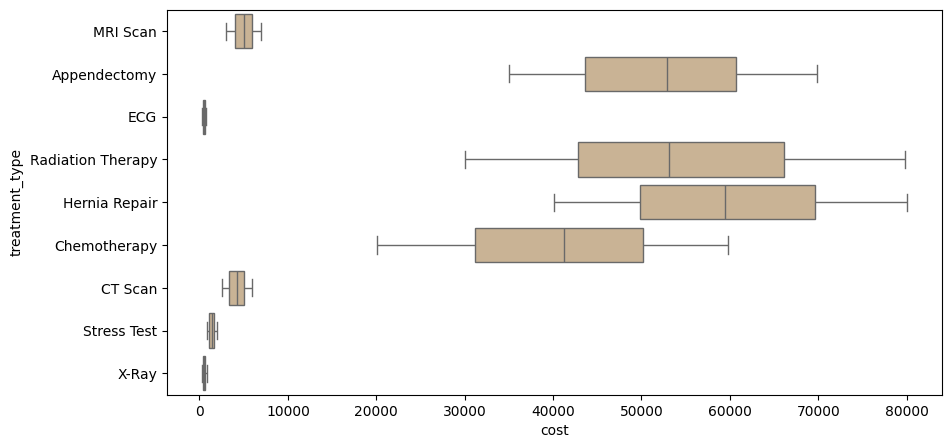

In [268]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df5,y='treatment_type',x='cost',color='tan')
plt.show()

###### Inference - All treatment types show a moderate level of cost variation, indicating that the price is generally consistent across all services, with no treatment exhibiting extreme price fluctuations 

##### 5) Treatment Utilization Distribution

In [269]:
res = df5.groupby('treatment_type')['treatment_id'].nunique().reset_index()
res.sort_values('treatment_id',ascending=False,inplace=True)
res.columns = ['Treatment Type','Treatment Count']
total_treatments = res['Treatment Count'].sum()
res['Percentage'] = round((res['Treatment Count'] / total_treatments)*100,2)
res['Cumulative_%'] = res['Percentage'].cumsum()
# res
table_res = res.copy()
table_res['Percentage'] = table_res['Percentage'].astype(str) + '%'
table_res['Cumulative_%'] = round(table_res['Cumulative_%'],2).astype(str) + '%'
table_res.set_index('Treatment Type',inplace=True)
table_res

,Treatment Count,Percentage,Cumulative_%
Treatment Type,,,
ECG,951,14.09%,14.09%
Stress Test,934,13.84%,27.93%
Chemotherapy,770,11.41%,39.34%
Appendectomy,764,11.32%,50.66%
Radiation Therapy,752,11.14%,61.8%
Hernia Repair,714,10.58%,72.38%
MRI Scan,652,9.66%,82.04%
X-Ray,615,9.11%,91.15%
CT Scan,598,8.86%,100.01%


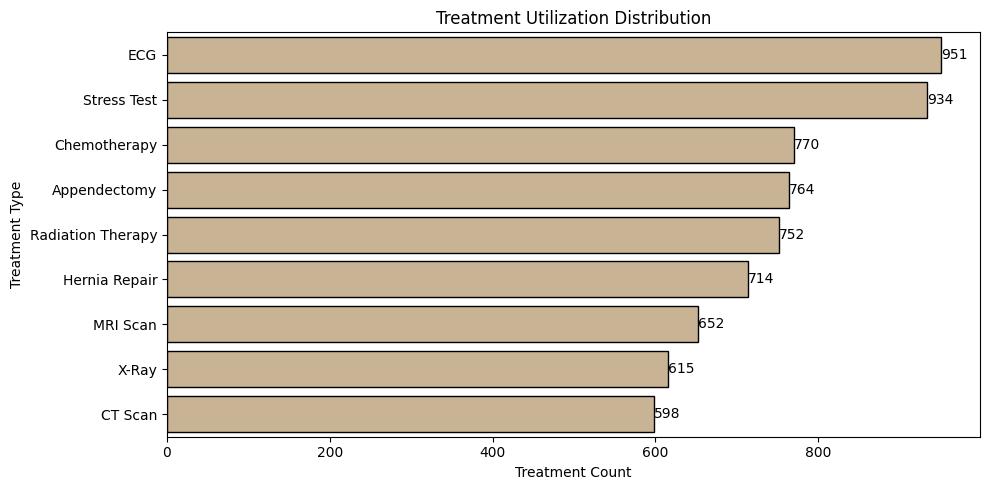

In [270]:
plt.figure(figsize=(10,5))
ax = sns.barplot(data=res,y='Treatment Type',x='Treatment Count',edgecolor='black',color='tan')
ax.bar_label(ax.containers[0])
plt.title(f'Treatment Utilization Distribution')
plt.tight_layout()
plt.show()

###### Inference - Treatment demand is fairly evenly distributed across treatment types, indicating balanced utilization with no single treatment dominating overall service delivery.

##### 6) Treatment Billing Conversion Analysis

In [271]:
total_tr = df5['treatment_id'].nunique()
total_tr_per = str(round((total_tr / total_tr)*100,2)) + '%'
samp = pd.merge(df5,df3,on='treatment_id',how='left')
# samp.head()
tr_with_bill = samp['treatment_id'][~samp['bill_id'].isnull()].nunique()
tr_with_bill_per = str(round((tr_with_bill / total_tr)*100,2)) + '%'
tr_without_bill = total_tr - tr_with_bill
tr_without_bill_per = str(round((tr_without_bill / total_tr)*100,2)) + '%'
res = pd.DataFrame({'Treatment Billing Status':['Total Treatments','Treatments with Billing','Treatments without Billing'],
                   'Treatment Count':[total_tr,tr_with_bill,tr_without_bill],
                   'Percentage':[total_tr_per,tr_with_bill_per,tr_without_bill_per]})
res

,Treatment Billing Status,Treatment Count,Percentage
0,Total Treatments,6750,100.0%
1,Treatments with Billing,6544,96.95%
2,Treatments without Billing,206,3.05%


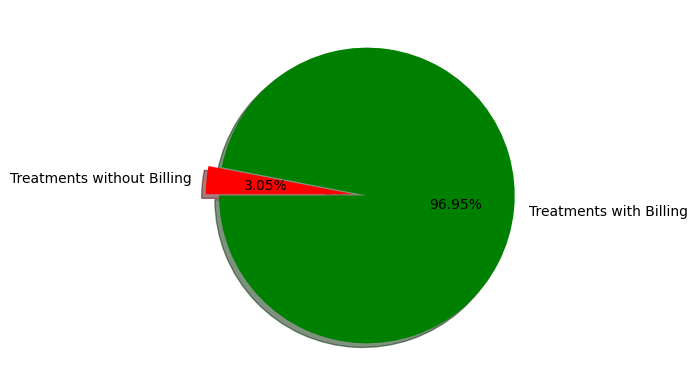

In [272]:
table_res = res.iloc[1::,:]
plt.pie(x=table_res['Treatment Count'],labels=table_res['Treatment Billing Status'],
        autopct='%.2f%%',explode=(0.09,0),colors=['green','red'],startangle=180,shadow=True)
plt.show()

###### Inference - The analysis shows that majority of the treatments are successfully billed, with a small portion remains unbilled, indicating a minor but important opportunity to improve revenue capture.  

## Executive Summary
This project analyzes a synthetically generated healthcare dataset representing operations
across multiple hospitals to evaluate patient trends, doctor activity, appointment behavior,
billing performance, and treatment utilization.

Key outcomes from the analysis show that patient registrations and appointments remain
relatively stable over time with moderate fluctuations. Revenue contribution is slightly
higher in a few top cities, while overall contribution across other major cities remains
fairly balanced. Doctor workload and revenue contribution are also evenly distributed,
with only small differences among top-performing doctors. Appointment cancellations and
no-shows vary month to month, with cancellations consistently higher, indicating recurring
loss of appointment capacity. Billing analysis reveals a small but notable gap between
billable appointments and actual billing, pointing to minor revenue leakage. Treatment
analysis shows that some frequently performed treatments generate lower revenue, while a
few less frequent treatments contribute higher revenue, with moderate cost variation and
balanced utilization across treatment types.

Overall, the findings provide a data-driven understanding of healthcare operations and
highlight areas where efficiency can be improved, such as reducing appointment losses,
strengthening billing alignment, and supporting better operational decision-making.

## Key Insights Summary
- Patient registrations and appointments remain relatively stable over time, with moderate month-to-month fluctuations.
- Revenue contribution is slightly higher in a few top cities, while other major cities show fairly balanced performance.
- Doctor workload and revenue contribution are evenly distributed, with only small differences among top-performing doctors.
- Appointment cancellations and no-shows vary across months, with cancellations consistently higher, leading to repeated loss of appointment slots.
- Billing records show a small gap between billable appointments and actual billing, indicating minor revenue leakage.
- Some treatments are performed frequently but generate lower revenue, while a few less frequent treatments contribute higher revenue.
- Treatment utilization is fairly balanced across treatment types, with no single treatment dominating overall service delivery.

## Business Recommendations
- Send reminders to patients to reduce appointment cancellations and no-shows.
- Review appointment schedules to make better use of available time slots.
- Regularly check that all completed appointments have matching billing records.
- Focus on improving performance in cities with relatively lower revenue.
- Review pricing of treatments that are done frequently but earn less revenue.
- Use specialization-wise demand to plan doctor workload more effectively.

## Conclusion
This project shows how healthcare data can be used to understand overall hospital
performance. By analyzing patients, doctors, appointments, billing, and treatments,
the analysis helps identify patterns in demand, resource usage, and revenue flow.

The project highlights areas where operations can be improved, such as managing
appointment cancellations, ensuring billing accuracy, and understanding treatment
revenue differences. Overall, this capstone demonstrates the practical use of data
analysis to support better planning and decision-making in healthcare.